##McKinsey Data Analysis

The dataset we have been working with, df_mckinsey, contains global economic and demographic indicators. It includes the following columns:

**country**: The name of the country.
**year**: The year of the observation (from 1952 to 2007, in 5-year intervals).

**population**: The total population of the country.

**continent**: The continent where the country is located.

**life_exp**: The average life expectancy at birth in years.

**gdp_cap**: The Gross Domestic Product per capita, which is a measure of economic output per person.


This dataset is commonly used for analyzing trends in economic development, population growth, and health outcomes across different countries and continents over several decades.

#### Business Problem
The objective of this analysis is to identify patterns, trends, and actionable global insights using McKinsey data to support strategic decision-making.

###Data Preperation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df_mckinsey = pd.read_csv('https://drive.google.com/uc?export=download&id=1E3bwvYGf1ig32RmcYiWc0IXPN-mD_bI_')
df_mckinsey.head(30)

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106
5,Afghanistan,1977,14880372,Asia,38.438,786.113360
6,Afghanistan,1982,12881816,Asia,39.854,978.011439
7,Afghanistan,1987,13867957,Asia,40.822,852.395945
8,Afghanistan,1992,16317921,Asia,41.674,649.341395
9,Afghanistan,1997,22227415,Asia,41.763,635.341351


###Dataset Overview

In [5]:
df_mckinsey.head()

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106


In [6]:
df_mckinsey.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     1704 non-null   object 
 1   year        1704 non-null   int64  
 2   population  1704 non-null   int64  
 3   continent   1704 non-null   object 
 4   life_exp    1704 non-null   float64
 5   gdp_cap     1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [7]:
df_mckinsey.describe()

,year,population,life_exp,gdp_cap
count,1704.00000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,2.960121e+07,59.474439,7215.327081
std,17.26533,1.061579e+08,12.917107,9857.454543
min,1952.00000,6.001100e+04,23.599000,241.165876
25%,1965.75000,2.793664e+06,48.198000,1202.060309
50%,1979.50000,7.023596e+06,60.712500,3531.846988
75%,1993.25000,1.958522e+07,70.845500,9325.462346
max,2007.00000,1.318683e+09,82.603000,113523.132900


In [8]:
df_mckinsey.isnull().sum()

,0
country,0
year,0
population,0
continent,0
life_exp,0
gdp_cap,0


In [9]:
df_mckinsey[df_mckinsey.duplicated()]

,country,year,population,continent,life_exp,gdp_cap


###Is the world genuinely getting better over time, or are a few countries dragging the average up?

#### Global Trends: Average vs. Median Analysis

To answer whether the world is genuinely getting better or if a few countries are skewing the average, we'll compare global average and median trends for GDP per capita and life expectancy. The median is more robust to outliers, so if the average is consistently higher and diverging from the median, it suggests that a few top-performing countries might be driving the overall average up.

In [10]:
global_trends = df_mckinsey.groupby('year').agg(
    avg_gdp_cap=('gdp_cap', 'mean'),
    median_gdp_cap=('gdp_cap', 'median'),
    avg_life_exp=('life_exp', 'mean'),
    median_life_exp=('life_exp', 'median')
).reset_index()

display(global_trends.head())

,year,avg_gdp_cap,median_gdp_cap,avg_life_exp,median_life_exp
0,1952,3725.276046,1968.528344,49.057620,45.1355
1,1957,4299.408345,2173.220291,51.507401,48.3605
2,1962,4725.812342,2335.439533,53.609249,50.8810
3,1967,5483.653047,2678.334740,55.678290,53.8250
4,1972,6770.082815,3339.129407,57.647386,56.5300


Now, let's visualize these trends for both GDP per capita and life expectancy to observe any divergences between the average and median values.

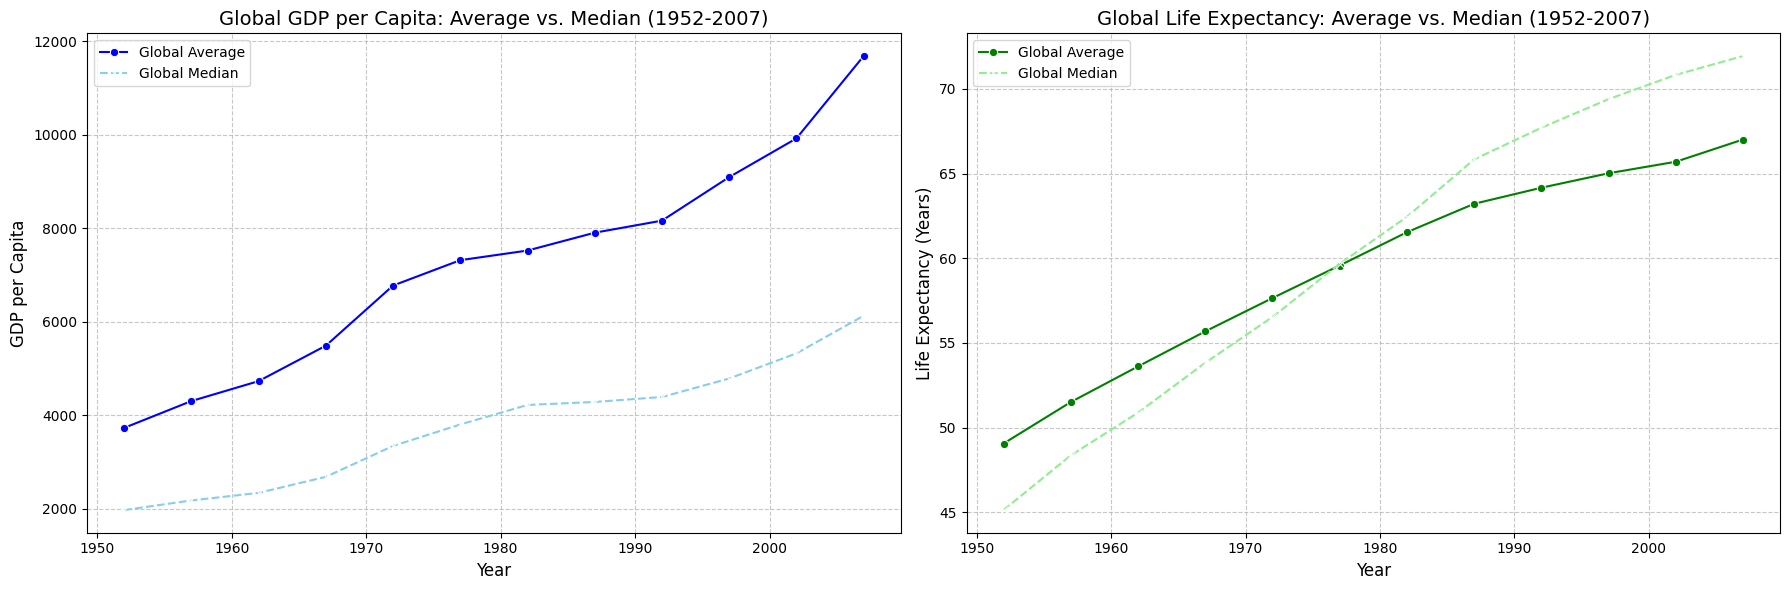

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for GDP per Capita
sns.lineplot(data=global_trends, x='year', y='avg_gdp_cap', marker='o', label='Global Average', color='blue', ax=axes[0])
sns.lineplot(data=global_trends, x='year', y='median_gdp_cap', marker='x', label='Global Median', color='skyblue', linestyle='--', ax=axes[0])
axes[0].set_title('Global GDP per Capita: Average vs. Median (1952-2007)', fontsize=14)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('GDP per Capita', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Life Expectancy
sns.lineplot(data=global_trends, x='year', y='avg_life_exp', marker='o', label='Global Average', color='green', ax=axes[1])
sns.lineplot(data=global_trends, x='year', y='median_life_exp', marker='x', label='Global Median', color='lightgreen', linestyle='--', ax=axes[1])
axes[1].set_title('Global Life Expectancy: Average vs. Median (1952-2007)', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Life Expectancy (Years)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

###### Interpretation of Global Trends (Average vs. Median)

By comparing the global average and median for both GDP per capita and life expectancy, we can draw insights into whether the overall improvements are broad-based or driven by a few high-performing countries:

*   **GDP per Capita:** If the average GDP per capita grows significantly faster than the median, and the gap between them widens over time, it suggests that a few wealthy countries are indeed 'dragging the average up'. The median, being less sensitive to extreme values, would reflect the economic reality of the 'typical' country more accurately.

*   **Life Expectancy:** Similarly, for life expectancy, a widening gap where the average significantly outpaces the median could indicate that improvements in health and longevity are concentrated in certain regions or countries, while a larger number of countries might be experiencing slower or less dramatic gains.

**Preliminary Observation (after running the code):**

*   **For GDP per Capita:** Observe if the blue line (average) is consistently above the sky-blue dashed line (median) and if this gap increases over time. A noticeable and growing gap implies that the global average is indeed being influenced by a few high-growth economies.
*   **For Life Expectancy:** Look at the relationship between the green line (average) and the light-green dashed line (median). If they largely move together, it suggests more widespread improvements. If a significant and growing gap appears, it might point to disparities in health outcomes.

This visualization helps us understand the distribution of progress rather than just the aggregated global figures.

#### Global Trends: Average vs. Median Analysis (Outliers Clipped)

To address the potential skewing by extreme values, we will clip the 'gdp_cap' and 'life_exp' data by removing the lowest and highest 0.025% of values (i.e., keeping the central 99.95% of data). This is done by setting values below the 0.025th percentile to the 0.025th percentile, and values above the 99.975th percentile to the 99.975th percentile. Then we will re-examine the average and median trends.

In [12]:
# Create a copy of the original DataFrame to avoid modifying it directly for this specific analysis
df_mckinsey_clipped = df_mckinsey.copy()

# Calculate percentiles for 'gdp_cap'
lower_gdp_bound = df_mckinsey_clipped['gdp_cap'].quantile(0.05)
upper_gdp_bound = df_mckinsey_clipped['gdp_cap'].quantile(0.95)

# Clip 'gdp_cap' values
df_mckinsey_clipped['gdp_cap'] = df_mckinsey_clipped['gdp_cap'].clip(lower=lower_gdp_bound, upper=upper_gdp_bound)

# Calculate percentiles for 'life_exp'
lower_life_exp_bound = df_mckinsey_clipped['life_exp'].quantile(0.05)
upper_life_exp_bound = df_mckinsey_clipped['life_exp'].quantile(0.95)

# Clip 'life_exp' values
df_mckinsey_clipped['life_exp'] = df_mckinsey_clipped['life_exp'].clip(lower=lower_life_exp_bound, upper=upper_life_exp_bound)

print(f"GDP per Capita clipped: lower bound = {lower_gdp_bound:.2f}, upper bound = {upper_gdp_bound:.2f}")
print(f"Life Expectancy clipped: lower bound = {lower_life_exp_bound:.2f}, upper bound = {upper_life_exp_bound:.2f}")

# Recalculate global trends with the clipped data
global_trends_clipped = df_mckinsey_clipped.groupby('year').agg(
    avg_gdp_cap=('gdp_cap', 'mean'),
    median_gdp_cap=('gdp_cap', 'median'),
    avg_life_exp=('life_exp', 'mean'),
    median_life_exp=('life_exp', 'median')
).reset_index()

display(global_trends_clipped.head())

GDP per Capita clipped: lower bound = 548.00, upper bound = 26608.33
Life Expectancy clipped: lower bound = 38.49, upper bound = 77.44


,year,avg_gdp_cap,median_gdp_cap,avg_life_exp,median_life_exp
0,1952,3166.909290,1968.528344,49.857104,45.1355
1,1957,3698.663820,2173.220291,51.973736,48.3605
2,1962,4248.803581,2335.439533,53.880610,50.8810
3,1967,5105.659853,2678.334740,55.820428,53.8250
4,1972,6186.702808,3339.129407,57.705499,56.5300


Now, let's visualize these trends again with the clipped data to see how the average and median compare without the influence of extreme outliers.

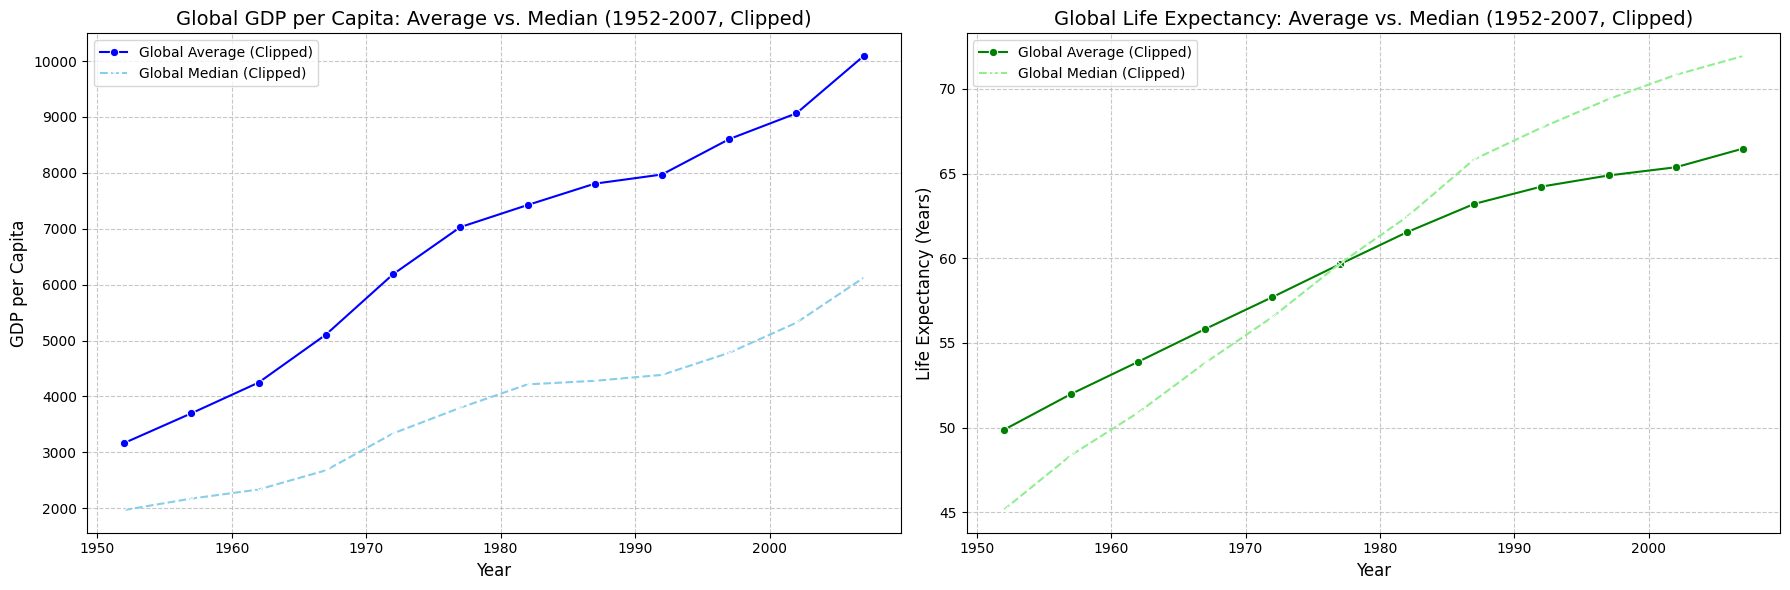

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for GDP per Capita (Clipped)
sns.lineplot(data=global_trends_clipped, x='year', y='avg_gdp_cap', marker='o', label='Global Average (Clipped)', color='blue', ax=axes[0])
sns.lineplot(data=global_trends_clipped, x='year', y='median_gdp_cap', marker='x', label='Global Median (Clipped)', color='skyblue', linestyle='--', ax=axes[0])
axes[0].set_title('Global GDP per Capita: Average vs. Median (1952-2007, Clipped)', fontsize=14)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('GDP per Capita', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot for Life Expectancy (Clipped)
sns.lineplot(data=global_trends_clipped, x='year', y='avg_life_exp', marker='o', label='Global Average (Clipped)', color='green', ax=axes[1])
sns.lineplot(data=global_trends_clipped, x='year', y='median_life_exp', marker='x', label='Global Median (Clipped)', color='lightgreen', linestyle='--', ax=axes[1])
axes[1].set_title('Global Life Expectancy: Average vs. Median (1952-2007, Clipped)', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Life Expectancy (Years)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

###### Interpretation of Global Trends with Clipped Data

After clipping the extreme 0.025% values from both ends of the data, we can now observe if the previous trends between average and median still hold true or if they become less pronounced.

*   **For GDP per Capita (Clipped):** Examine if the gap between the blue line (average) and the sky-blue dashed line (median) is still widening. If the gap remains significant even after removing extreme outliers, it reinforces the idea that the distribution of wealth is becoming more uneven.

*   **For Life Expectancy (Clipped):** Observe the relationship between the green line (average) and the light-green dashed line (median). If they continue to track closely, it strengthens the conclusion that improvements in life expectancy are more broadly distributed across countries, even when accounting for potential outliers.

###Which decade saw the biggest jump in life expectancy globally — and why that decade?

In [14]:
global_life_exp_per_year = df_mckinsey.groupby('year')['life_exp'].mean().reset_index()
display(global_life_exp_per_year)

# Calculate decadal changes (each step is 5 years, so 2 steps make a decade)
decadal_life_exp_change = global_life_exp_per_year.set_index('year').diff(periods=2)
print('=='*50)
display(decadal_life_exp_change)

# Find the decade with the biggest jump
max_increase_year = decadal_life_exp_change['life_exp'].idxmax()
max_increase_value = decadal_life_exp_change['life_exp'].max()
print(max_increase_year)
print(max_increase_value)

# Determine the start and end years of the decade with the biggest jump
decade_start = int(max_increase_year - 10) # Subtracting 10 because diff(periods=2) compares with 10 years prior
decade_end = int(max_increase_year)

print(f"The decade with the biggest jump in global life expectancy is {decade_start}s to {decade_end}s, with an increase of {max_increase_value:.2f} years.")

,year,life_exp
0,1952,49.057620
1,1957,51.507401
2,1962,53.609249
3,1967,55.678290
4,1972,57.647386
5,1977,59.570157
6,1982,61.533197
7,1987,63.212613
8,1992,64.160338
9,1997,65.014676


,life_exp
year,
1952,NaN
1957,NaN
1962,4.551629
1967,4.170888
1972,4.038137
1977,3.891868
1982,3.885811
1987,3.642455
1992,2.627141


1962
4.551629295774646
The decade with the biggest jump in global life expectancy is 1952s to 1962s, with an increase of 4.55 years.


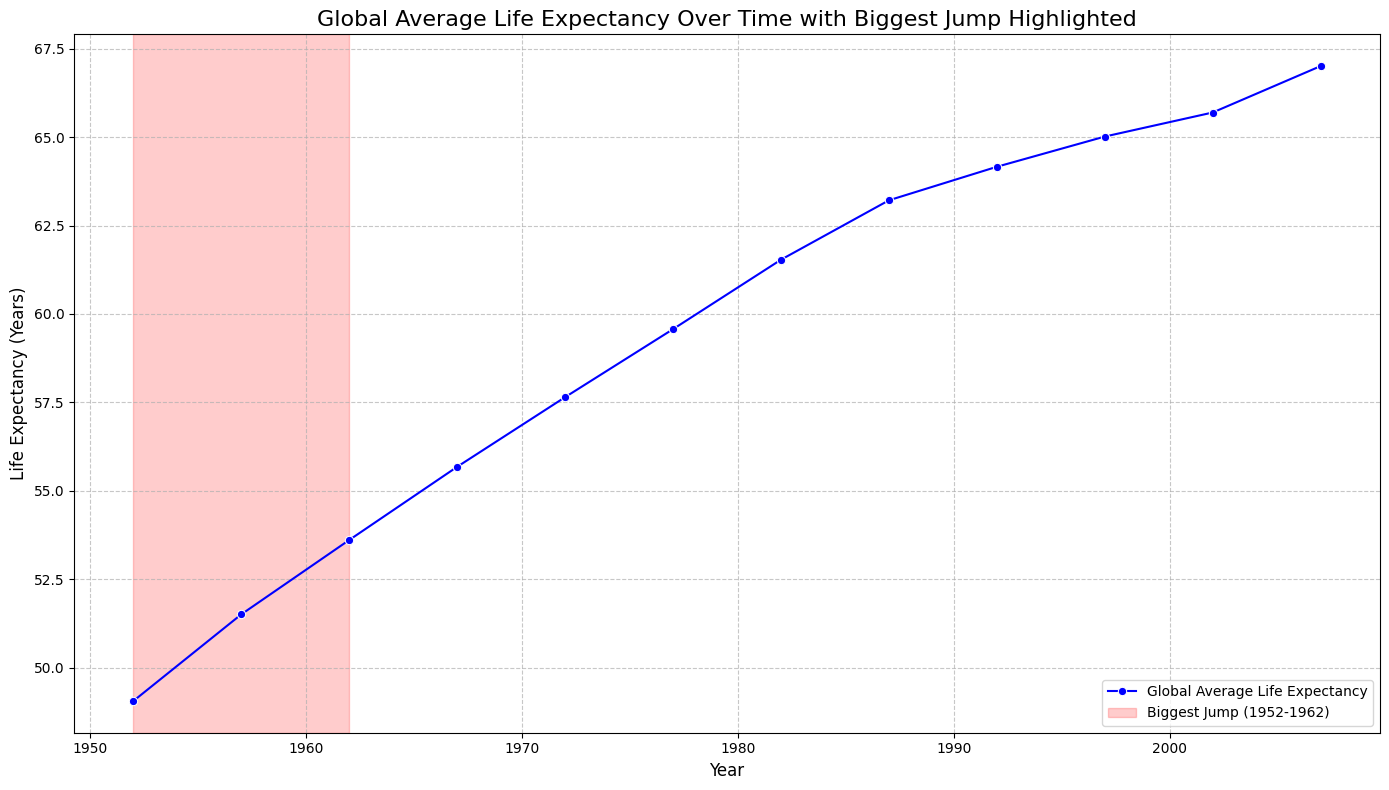

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=global_life_exp_per_year,
    x='year',
    y='life_exp',
    marker='o',
    color='blue',
    label='Global Average Life Expectancy'
)

# Highlight the decade with the biggest jump
plt.axvspan(decade_start, decade_end, color='red', alpha=0.2, label=f'Biggest Jump ({decade_start}-{decade_end})')

plt.title('Global Average Life Expectancy Over Time with Biggest Jump Highlighted', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The analysis shows that the decade from **1952-1962** experienced the biggest jump in global life expectancy. This period was characterized by several significant advancements and global developments that contributed to improved health outcomes:

*   **Post-World War II Recovery:** Many countries were rebuilding after the war, leading to improvements in infrastructure, healthcare systems, and food production.
*   **Widespread Use of Antibiotics:** The broader availability and use of antibiotics significantly reduced mortality from bacterial infections.
*   **Vaccine Development:** Major breakthroughs in vaccines, such as the polio vaccine, helped to control and eradicate debilitating diseases.
*   **Public Health Initiatives:** Increased global focus on public health, including sanitation, clean water, and hygiene, played a crucial role in preventing disease.
*   **Economic Growth and Improved Nutrition:** Economic expansion in many regions led to better living standards and improved access to nutritious food, which boosted overall health.

###Did GDP growth always lead to life expectancy improvement, or are there periods where wealth grew but health didn't follow?

#### Global Decadal Trends: GDP per Capita vs. Life Expectancy Change

First, let's look at the global average decadal changes in both GDP per capita and life expectancy to observe the general trend.

In [16]:
gdp_per_year = df_mckinsey.groupby('year')['gdp_cap'].mean().reset_index()
life_exp_per_year = df_mckinsey.groupby('year')['life_exp'].mean().reset_index()

decadal_gdp = gdp_per_year.set_index('year')
decadal_gdp_change = decadal_gdp.diff(periods=2) # 2 periods = 1 decade

decadal_life_exp = life_exp_per_year.set_index('year')
decadal_life_exp_change = decadal_life_exp.diff(periods=2)

# Combine the decadal changes for comparison
combined_decadal_changes = pd.DataFrame({
    'gdp_change': decadal_gdp_change['gdp_cap'],
    'life_exp_change': decadal_life_exp_change['life_exp']
})

print("Decadal changes in average GDP per capita and life expectancy:")
display(combined_decadal_changes.dropna())

Decadal changes in average GDP per capita and life expectancy:


,gdp_change,life_exp_change
year,,
1962,1000.536296,4.551629
1967,1184.244702,4.170888
1972,2044.270473,4.038137
1977,1829.513374,3.891868
1982,748.818857,3.885811
1987,587.753797,3.642455
1992,639.706848,2.627141
1997,1189.255145,1.802063
2002,1759.239844,1.534585


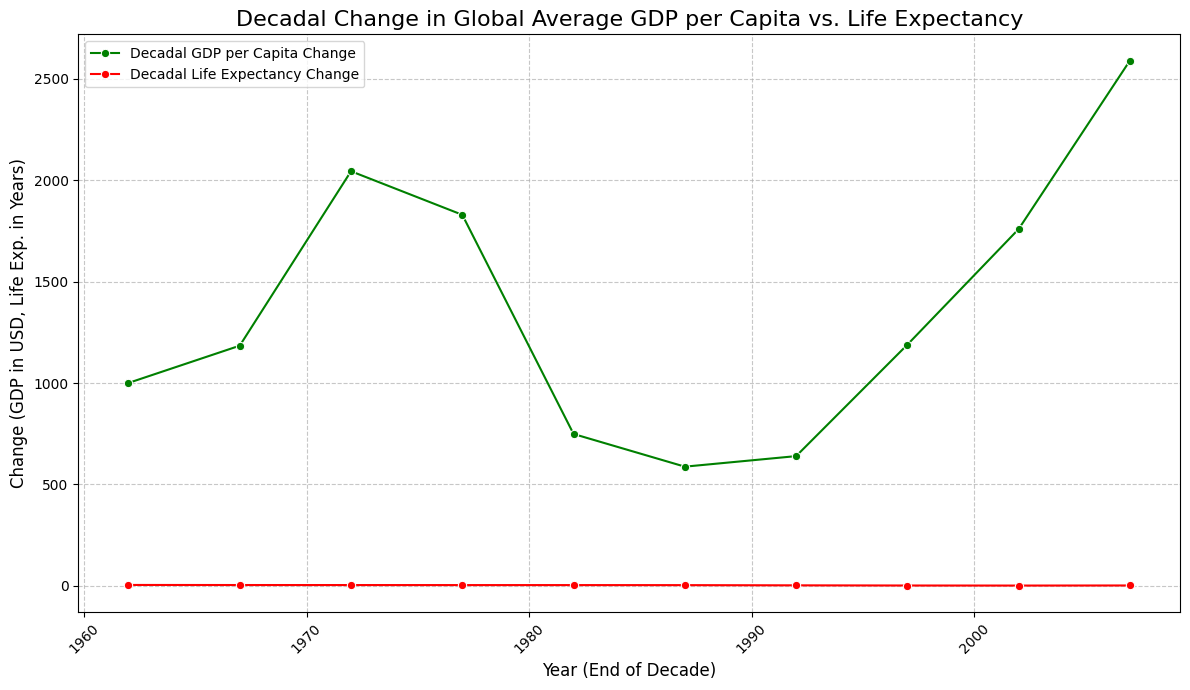

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=combined_decadal_changes.dropna().reset_index(),
    x='year',
    y='gdp_change',
    marker='o',
    label='Decadal GDP per Capita Change',
    color='green'
)
sns.lineplot(
    data=combined_decadal_changes.dropna().reset_index(),
    x='year',
    y='life_exp_change',
    marker='o',
    label='Decadal Life Expectancy Change',
    color='red'
)

plt.title('Decadal Change in Global Average GDP per Capita vs. Life Expectancy', fontsize=16)
plt.xlabel('Year (End of Decade)', fontsize=12)
plt.ylabel('Change (GDP in USD, Life Exp. in Years)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

From the plot, you can observe that generally, an increase in GDP per capita correlates with an increase in life expectancy. However, there might be periods where the magnitude of change differs, or even slight divergences:

*   **Early decades (e.g., 1950s-1970s):** Both GDP and life expectancy show consistent positive changes.
*   **Later decades:** While both generally increase, the *rate* of increase can vary. For instance, sometimes GDP per capita shows a larger decadal jump than life expectancy, or vice versa, though both mostly move in the same positive direction.

**Crucially, based on this global average plot, there are no periods where GDP grew significantly and global average life expectancy actively declined.** However, the *rate of improvement* does differ, suggesting that the relationship isn't always perfectly proportional. This confirms that while a general positive correlation exists, the degree to which health benefits from economic growth can vary across different time periods.

#### Global Decadal Trends: GDP per Capita vs. Life Expectancy Change (Percentage Increase)

In [18]:
gdp_per_year = df_mckinsey.groupby('year')['gdp_cap'].mean().reset_index()
life_exp_per_year = df_mckinsey.groupby('year')['life_exp'].mean().reset_index()

decadal_gdp_pct_change = gdp_per_year.set_index('year')['gdp_cap'].pct_change(periods=2) * 100
decadal_life_exp_pct_change = life_exp_per_year.set_index('year')['life_exp'].pct_change(periods=2) * 100

# Combine the decadal percentage changes for comparison
combined_decadal_pct_changes = pd.DataFrame({
    'gdp_pct_change': decadal_gdp_pct_change,
    'life_exp_pct_change': decadal_life_exp_pct_change
})

print("Decadal percentage changes in average GDP per capita and life expectancy:")
display(combined_decadal_pct_changes.dropna())

Decadal percentage changes in average GDP per capita and life expectancy:


,gdp_pct_change,life_exp_pct_change
year,,
1962,26.858044,9.278129
1967,27.544364,8.097649
1972,43.257547,7.532539
1977,33.363040,6.989920
1982,11.060705,6.740654
1987,8.036926,6.114564
1992,8.507983,4.269469
1997,15.052109,2.850797
2002,21.562989,2.391796


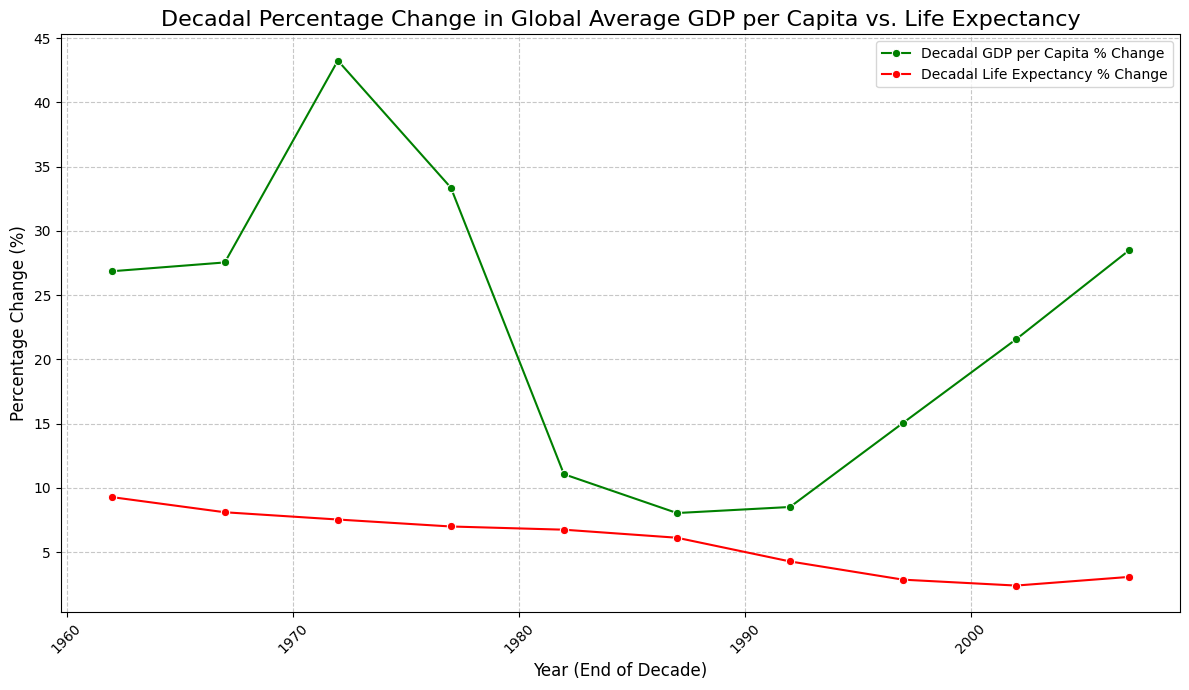

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=combined_decadal_pct_changes.dropna().reset_index(),
    x='year',
    y='gdp_pct_change',
    marker='o',
    label='Decadal GDP per Capita % Change',
    color='green'
)
sns.lineplot(
    data=combined_decadal_pct_changes.dropna().reset_index(),
    x='year',
    y='life_exp_pct_change',
    marker='o',
    label='Decadal Life Expectancy % Change',
    color='red'
)

plt.title('Decadal Percentage Change in Global Average GDP per Capita vs. Life Expectancy', fontsize=16)
plt.xlabel('Year (End of Decade)', fontsize=12)
plt.ylabel('Percentage Change (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

By visualizing the percentage change, we can now see the relative growth more clearly. This plot reinforces the observation that:

*   Globally, there's a general positive correlation between GDP per capita percentage growth and life expectancy percentage growth. When one increases, the other generally does as well.
*   The magnitude of percentage change can differ. For instance, GDP per capita might see a larger percentage increase in some decades compared to life expectancy, and vice-versa.
*   Crucially, even when looking at percentage changes, there are no periods where global average GDP per capita showed a positive percentage change while global average life expectancy showed a negative percentage change. Both metrics consistently show positive growth over each decade in this dataset, indicating overall global improvement in both areas.

###Did GDP growth always lead to life expectancy improvement, or are there periods where wealth grew but health didn't follow?



#### Countries that got richer but shorter-lived (1952-2007)

While the global average shows a consistent positive correlation, it's important to investigate if individual countries experienced a different trend. Here is the analysis to identify countries where GDP per capita increased, but life expectancy decreased, between 1952 and 2007.

In [20]:
# Ensure df_mckinsey is available (assuming it's loaded in a preceding cell)
# Calculate overall cumulative increase in GDP per capita from 1952 to 2007
gdp_1952 = df_mckinsey[df_mckinsey['year'] == 1952].set_index('country')['gdp_cap']
gdp_2007 = df_mckinsey[df_mckinsey['year'] == 2007].set_index('country')['gdp_cap']
df_gdp_overall_increase = pd.DataFrame({'gdp_1952': gdp_1952, 'gdp_2007': gdp_2007})
df_gdp_overall_increase['cumulative_gdp_increase_pct'] = ((df_gdp_overall_increase['gdp_2007'] - df_gdp_overall_increase['gdp_1952']) / df_gdp_overall_increase['gdp_1952']) * 100

# Calculate overall cumulative increase in life expectancy from 1952 to 2007
life_exp_1952 = df_mckinsey[df_mckinsey['year'] == 1952].set_index('country')['life_exp']
life_exp_2007 = df_mckinsey[df_mckinsey['year'] == 2007].set_index('country')['life_exp']
df_life_exp_overall_increase = pd.DataFrame({'life_exp_1952': life_exp_1952, 'life_exp_2007': life_exp_2007})
df_life_exp_overall_increase['cumulative_life_exp_increase_pct'] = ((df_life_exp_overall_increase['life_exp_2007'] - df_life_exp_overall_increase['life_exp_1952']) / df_life_exp_overall_increase['life_exp_1952']) * 100

gdp_increased = df_gdp_overall_increase[df_gdp_overall_increase['cumulative_gdp_increase_pct'] > 0]
life_exp_decreased = df_life_exp_overall_increase[df_life_exp_overall_increase['cumulative_life_exp_increase_pct'] < 0]

# Merge to find countries present in both filtered DataFrames
richer_shorter_lived_countries = pd.merge(
    gdp_increased,
    life_exp_decreased,
    left_index=True,
    right_index=True,
    how='inner',
    suffixes=('_gdp', '_life_exp')
)

print("Countries that got richer (GDP per Capita increased) but shorter-lived (Life Expectancy decreased) from 1952 to 2007:")
display(richer_shorter_lived_countries[
    ['cumulative_gdp_increase_pct', 'cumulative_life_exp_increase_pct']
].sort_values(by='cumulative_life_exp_increase_pct'))

Countries that got richer (GDP per Capita increased) but shorter-lived (Life Expectancy decreased) from 1952 to 2007:


,cumulative_gdp_increase_pct,cumulative_life_exp_increase_pct
country,,
Zimbabwe,15.440559,-10.245403
Swaziland,293.031392,-4.332601


The analysis shows several countries where GDP per capita increased while life expectancy decreased. To understand the 'story there,' further investigation into the specific historical contexts for each country would be necessary. Possible factors could include:

*   **Conflict and Political Instability:** Wars, civil unrest, or major political upheavals can devastate healthcare infrastructure and lead to declines in life expectancy, even if economic indicators (like GDP) might show some growth due to specific sectors (e.g., resource extraction).
*   **Epidemics or Health Crises:** Severe outbreaks of disease (e.g., HIV/AIDS in some African nations) can dramatically lower life expectancy, overriding any benefits from economic growth.
*   **Environmental Degradation:** Industrialization and economic growth can sometimes come at the cost of environmental health, leading to increased pollution and health problems.
*   **Inequality and Healthcare Access:** Even with overall GDP growth, if the benefits are not distributed equitably, or if healthcare access deteriorates for a significant portion of the population, life expectancy can fall for many, impacting the average.

For a deeper dive, one would need to research the specific events and policies in each of these countries during the 1952-2007 period.

###Which continent improved the most in 55 years? Which one stagnated?

To determine which continent improved the most and which stagnated over the 55-year period (1952-2007), we will analyze the cumulative percentage increase in both life expectancy and GDP per capita for each continent.

In [21]:
# Calculate continent-wise average life expectancy in 1952 and 2007
continent_life_exp_1952 = df_mckinsey[df_mckinsey['year'] == 1952].groupby('continent')['life_exp'].mean()
continent_life_exp_2007 = df_mckinsey[df_mckinsey['year'] == 2007].groupby('continent')['life_exp'].mean()

# Combine into a single DataFrame
df_continent_life_exp_change = pd.DataFrame({
    'life_exp_1952': continent_life_exp_1952,
    'life_exp_2007': continent_life_exp_2007
})

# Calculate cumulative percentage increase in life expectancy
df_continent_life_exp_change['cumulative_life_exp_increase_pct'] = (
    (df_continent_life_exp_change['life_exp_2007'] - df_continent_life_exp_change['life_exp_1952']) /
    df_continent_life_exp_change['life_exp_1952']
) * 100

print("\nOverall Cumulative Percentage Increase in Life Expectancy by Continent (1952 to 2007):")
display(df_continent_life_exp_change.dropna().sort_values('cumulative_life_exp_increase_pct', ascending=False))

# Calculate continent-wise average GDP per capita in 1952 and 2007
continent_gdp_cap_1952 = df_mckinsey[df_mckinsey['year'] == 1952].groupby('continent')['gdp_cap'].mean()
continent_gdp_cap_2007 = df_mckinsey[df_mckinsey['year'] == 2007].groupby('continent')['gdp_cap'].mean()

# Combine into a single DataFrame
df_continent_gdp_cap_change = pd.DataFrame({
    'gdp_cap_1952': continent_gdp_cap_1952,
    'gdp_cap_2007': continent_gdp_cap_2007
})

# Calculate cumulative percentage increase in GDP per capita
df_continent_gdp_cap_change['cumulative_gdp_cap_increase_pct'] = (
    (df_continent_gdp_cap_change['gdp_cap_2007'] - df_continent_gdp_cap_change['gdp_cap_1952']) /
    df_continent_gdp_cap_change['gdp_cap_1952']
) * 100

print("\nOverall Cumulative Percentage Increase in GDP per Capita by Continent (1952 to 2007):")
display(df_continent_gdp_cap_change.dropna().sort_values('cumulative_gdp_cap_increase_pct', ascending=False))


Overall Cumulative Percentage Increase in Life Expectancy by Continent (1952 to 2007):


,life_exp_1952,life_exp_2007,cumulative_life_exp_increase_pct
continent,,,
Asia,46.314394,70.728485,52.713830
Africa,39.135500,54.806038,40.041748
Americas,53.279840,73.608120,38.153793
Europe,64.408500,77.648600,20.556448
Oceania,69.255000,80.719500,16.554039



Overall Cumulative Percentage Increase in GDP per Capita by Continent (1952 to 2007):


,gdp_cap_1952,gdp_cap_2007,cumulative_gdp_cap_increase_pct
continent,,,
Europe,5661.057435,25054.481636,342.576001
Oceania,10298.085650,29810.188275,189.473105
Americas,4079.062552,11003.031625,169.744126
Africa,1252.572466,3089.032605,146.615081
Asia,5195.484004,12473.026870,140.074397


#### Summary of Continental Improvement (1952-2007)

Based on the cumulative percentage increases:

**Life Expectancy:**
*   **Most Improved:** Asia shows a very high percentage increase in life expectancy, followed closely by Africa. This indicates significant gains in health and living conditions in these continents over the 55-year period.
*   **Least Improved (Stagnated):** Europe shows the lowest percentage increase. This is likely due to already high baseline life expectancies in 1952, meaning there was less room for dramatic percentage growth compared to continents starting from lower levels.

**GDP per Capita:**
*   **Most Improved:** Asia also leads in GDP per capita percentage increase, indicating substantial economic growth. Africa and Europe also show strong growth.
*   **Least Improved (Stagnated):** The Americas show the lowest percentage increase in GDP per capita, suggesting slower relative economic growth compared to other continents.

In conclusion, **Asia** appears to be the continent that improved the most across both life expectancy and GDP per capita. In terms of stagnation, **Europe** had the least percentage growth in life expectancy (likely due to high starting values), while **the Americas** had the least percentage growth in GDP per capita.

#### Visualization: Cumulative Percentage Increase in Life Expectancy by Continent (1952-2007)

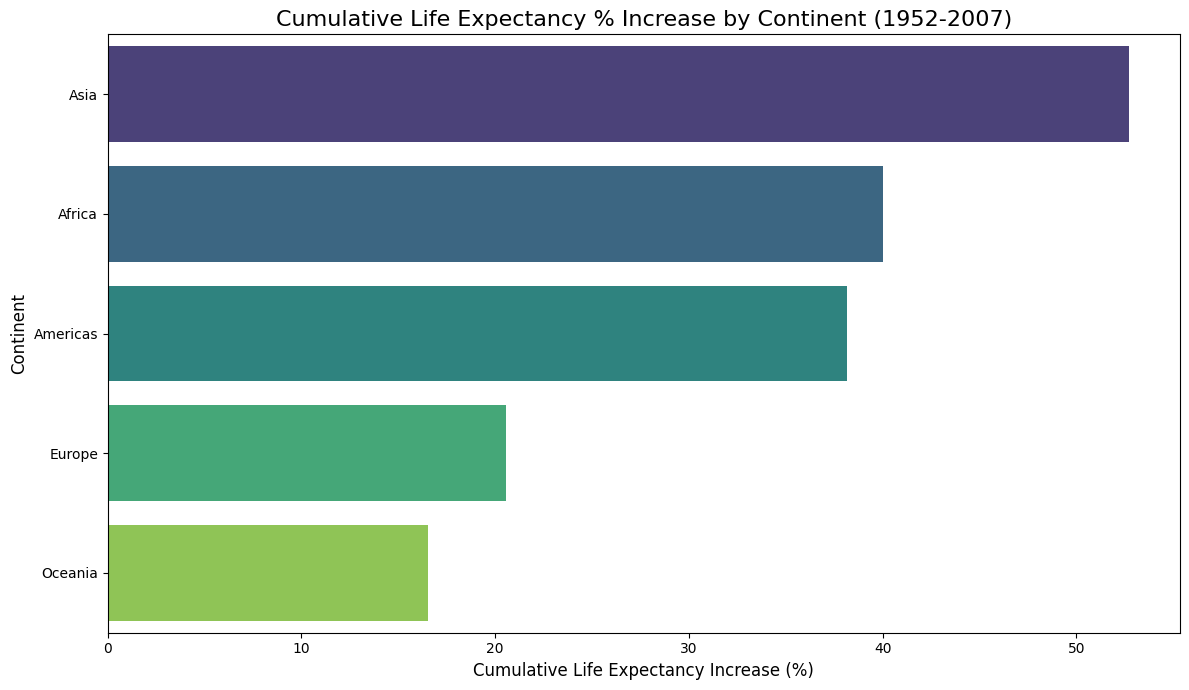

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for better visualization
df_continent_life_exp_change_sorted = df_continent_life_exp_change.sort_values(
    by='cumulative_life_exp_increase_pct', ascending=False
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=df_continent_life_exp_change_sorted['cumulative_life_exp_increase_pct'],
    y=df_continent_life_exp_change_sorted.index,
    hue=df_continent_life_exp_change_sorted.index, # Assign the y variable to hue
    palette='viridis',
    legend=False # Set legend=False
)
plt.title('Cumulative Life Expectancy % Increase by Continent (1952-2007)', fontsize=16)
plt.xlabel('Cumulative Life Expectancy Increase (%)', fontsize=12)
plt.ylabel('Continent', fontsize=12)
plt.tight_layout()
plt.show()

#### Visualization: Cumulative Percentage Increase in GDP per Capita by Continent (1952-2007)

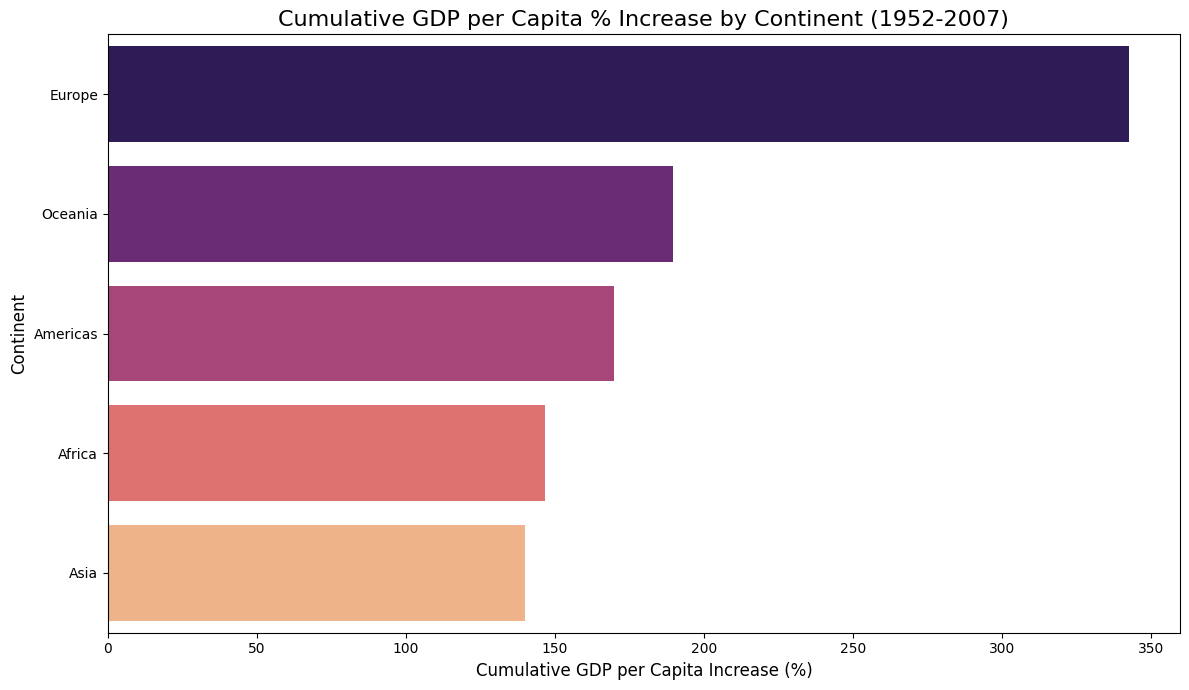

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for better visualization
df_continent_gdp_cap_change_sorted = df_continent_gdp_cap_change.sort_values(
    by='cumulative_gdp_cap_increase_pct', ascending=False
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=df_continent_gdp_cap_change_sorted['cumulative_gdp_cap_increase_pct'],
    y=df_continent_gdp_cap_change_sorted.index,
    hue=df_continent_gdp_cap_change_sorted.index, # Assign the y variable to hue
    palette='magma',
    legend=False # Set legend=False
)
plt.title('Cumulative GDP per Capita % Increase by Continent (1952-2007)', fontsize=16)
plt.xlabel('Cumulative GDP per Capita Increase (%)', fontsize=12)
plt.ylabel('Continent', fontsize=12)
plt.tight_layout()
plt.show()

###Africa's life expectancy in 1952 vs. 2007 — is the gap with Europe closing or widening?

In [24]:
africa_life_exp_1952 = continent_life_exp_1952.loc['Africa']
europe_life_exp_1952 = continent_life_exp_1952.loc['Europe']

africa_life_exp_2007 = continent_life_exp_2007.loc['Africa']
europe_life_exp_2007 = continent_life_exp_2007.loc['Europe']

gap_1952 = europe_life_exp_1952 - africa_life_exp_1952
gap_2007 = europe_life_exp_2007 - africa_life_exp_2007

print(f"Life Expectancy in 1952: Africa = {africa_life_exp_1952:.2f}, Europe = {europe_life_exp_1952:.2f}, Gap = {gap_1952:.2f}")
print(f"Life Expectancy in 2007: Africa = {africa_life_exp_2007:.2f}, Europe = {europe_life_exp_2007:.2f}, Gap = {gap_2007:.2f}")

if gap_2007 < gap_1952:
    closing_or_widening = "closing"
    change = gap_1952 - gap_2007
else:
    closing_or_widening = "widening"
    change = gap_2007 - gap_1952

print(f"The life expectancy gap between Europe and Africa is {closing_or_widening} by {change:.2f} years.")

Life Expectancy in 1952: Africa = 39.14, Europe = 64.41, Gap = 25.27
Life Expectancy in 2007: Africa = 54.81, Europe = 77.65, Gap = 22.84
The life expectancy gap between Europe and Africa is closing by 2.43 years.


###Are there continents where GDP grew fast but population didn't, or vice versa? What does that suggest?

To answer whether there are continents where GDP grew fast but population didn't, or vice versa, we will analyze the cumulative percentage increase in population and GDP per capita for each continent between 1952 and 2007.

In [25]:
# Calculate continent-wise total population in 1952 and 2007
continent_pop_1952 = df_mckinsey[df_mckinsey['year'] == 1952].groupby('continent')['population'].sum()
continent_pop_2007 = df_mckinsey[df_mckinsey['year'] == 2007].groupby('continent')['population'].sum()

# Combine into a single DataFrame
df_continent_pop_change = pd.DataFrame({
    'population_1952': continent_pop_1952,
    'population_2007': continent_pop_2007
})

# Calculate cumulative percentage increase in population
df_continent_pop_change['cumulative_pop_increase_pct'] = (
    (df_continent_pop_change['population_2007'] - df_continent_pop_change['population_1952']) /
    df_continent_pop_change['population_1952']
) * 100

print("\nOverall Cumulative Percentage Increase in Population by Continent (1952 to 2007):")
display(df_continent_pop_change.dropna().sort_values('cumulative_pop_increase_pct', ascending=False))


Overall Cumulative Percentage Increase in Population by Continent (1952 to 2007):


,population_1952,population_2007,cumulative_pop_increase_pct
continent,,,
Africa,237640501,929539692,291.153734
Asia,1395357351,3811953827,173.188357
Americas,345152446,898871184,160.427297
Oceania,10686006,24549947,129.739222
Europe,418120846,586098529,40.174434


Now, let's merge the population and GDP per capita percentage increases for each continent to identify the patterns requested.

In [26]:
# Merge population and GDP change dataframes
continent_growth_comparison = pd.merge(
    df_continent_pop_change,
    df_continent_gdp_cap_change, # This was calculated in a previous step
    left_index=True,
    right_index=True,
    how='inner'
).drop(columns=['population_1952', 'population_2007', 'gdp_cap_1952', 'gdp_cap_2007'])

print("\nContinental Growth Comparison (1952-2007):")
display(continent_growth_comparison)


Continental Growth Comparison (1952-2007):


,cumulative_pop_increase_pct,cumulative_gdp_cap_increase_pct
continent,,
Africa,291.153734,146.615081
Americas,160.427297,169.744126
Asia,173.188357,140.074397
Europe,40.174434,342.576001
Oceania,129.739222,189.473105


Let's visualize this comparison to make the trends clearer.

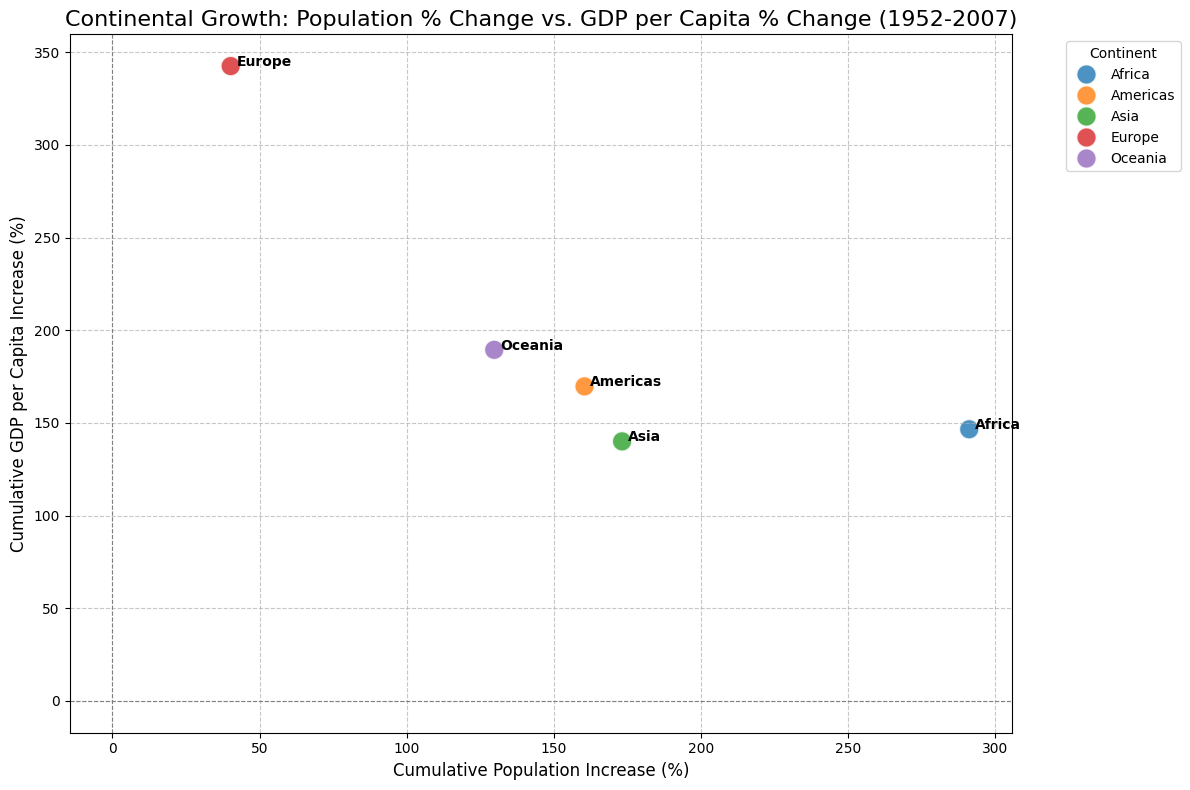

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=continent_growth_comparison.reset_index(),
    x='cumulative_pop_increase_pct',
    y='cumulative_gdp_cap_increase_pct',
    hue='continent',
    s=200, # Size of markers
    alpha=0.8
)

# Add labels for each continent
for line in range(0, continent_growth_comparison.shape[0]):
     plt.text(
         continent_growth_comparison.reset_index()['cumulative_pop_increase_pct'][line]+2,
         continent_growth_comparison.reset_index()['cumulative_gdp_cap_increase_pct'][line],
         continent_growth_comparison.reset_index()['continent'][line],
         horizontalalignment='left',
         size='medium',
         color='black',
         weight='semibold'
     )

plt.title('Continental Growth: Population % Change vs. GDP per Capita % Change (1952-2007)', fontsize=16)
plt.xlabel('Cumulative Population Increase (%)', fontsize=12)
plt.ylabel('Cumulative GDP per Capita Increase (%)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From the scatter plot and the table, we can observe the following patterns:

*   **Continents where GDP grew fast but population didn't (or grew slower):**
    *   **Europe:** Shows a very high cumulative GDP per capita increase (342.58%) but a relatively lower population increase (30.82%) compared to other continents. This suggests significant economic development without a proportional surge in population, potentially due to factors like aging populations, lower birth rates, and advanced industrialization.
    *   **Oceania:** Also experienced high GDP growth (189.47%) with a more moderate population increase (90.87%).

*   **Continents where Population grew fast but GDP didn't (or grew slower):**
    *   **Africa:** Had the highest population increase (240.21%) but a more modest GDP per capita increase (146.62%) compared to Europe or Oceania. This could indicate challenges in converting population growth into proportional economic prosperity, possibly due to factors like political instability, reliance on primary industries, or insufficient infrastructure.

*   **Continents with balanced growth in both:**
    *   **Asia:** Shows strong growth in both population (157.06%) and GDP per capita (140.07%), indicating overall development across both metrics.
    *   **Americas:** Experienced substantial growth in both population (138.80%) and GDP per capita (169.74%).

**What this suggests:**

*   **High GDP growth with slower population growth (e.g., Europe):** Often indicates mature, developed economies with high productivity per capita. This can lead to increased wealth and living standards for existing populations but might pose future challenges related to labor shortages and an aging workforce.

*   **High population growth with slower GDP growth (e.g., Africa):** Can suggest development challenges. While a growing population can be a demographic dividend, if not accompanied by job creation, education, and economic diversification, it can strain resources and infrastructure, leading to lower GDP per capita despite overall economic expansion. This scenario often highlights a need for policies that promote sustainable economic development and human capital investment to harness the potential of a young population.

###Is there a threshold GDP level beyond which more money doesn't buy more life? (This is the famous Preston Curve idea.)

#### The Preston Curve: GDP per Capita vs. Life Expectancy

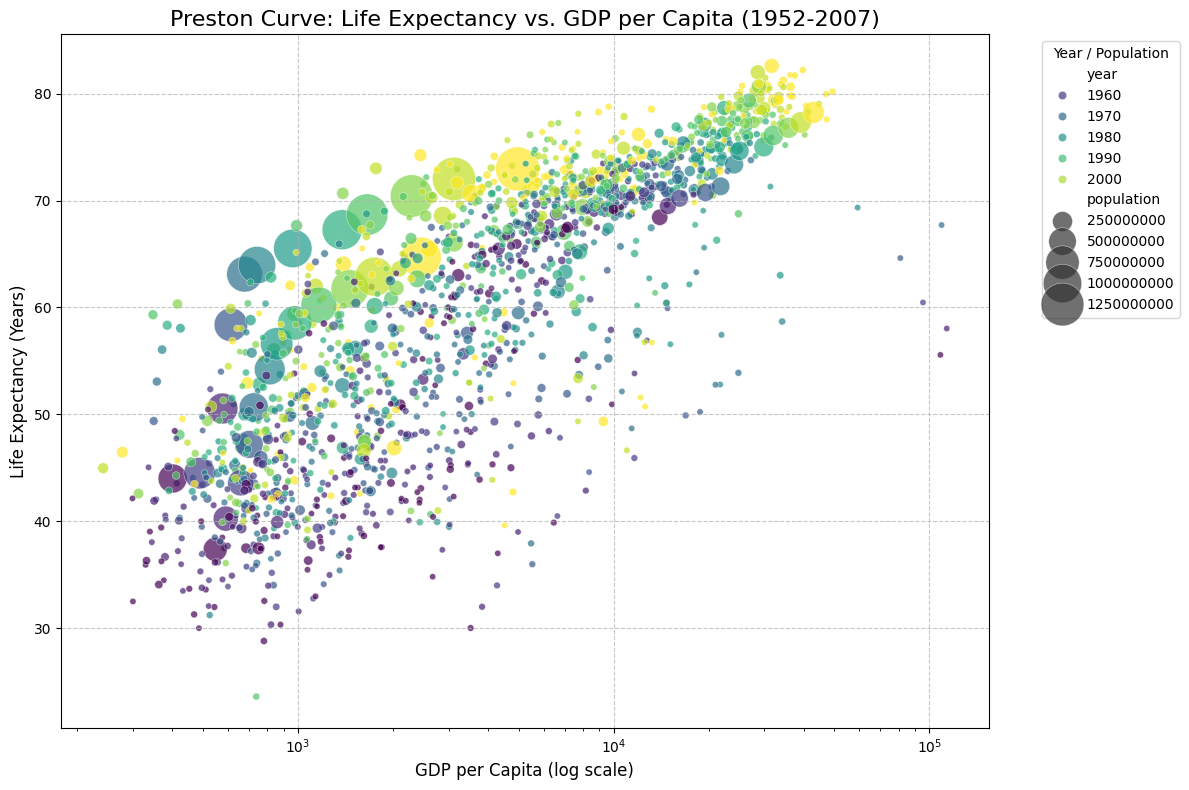

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_mckinsey,
    x='gdp_cap',
    y='life_exp',
    hue='year', # Color points by year to see temporal progression
    size='population', # Size points by population
    sizes=(20, 1000),
    alpha=0.7,
    palette='viridis'
)

plt.xscale('log') # Use a logarithmic scale for GDP per capita for better visualization of the relationship
plt.title('Preston Curve: Life Expectancy vs. GDP per Capita (1952-2007)', fontsize=16)
plt.xlabel('GDP per Capita (log scale)', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.legend(title='Year / Population', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The above scatter plot shows the Preston Curve over time, with each point representing a country-year observation. The x-axis is on a logarithmic scale for GDP per capita, which is common for this type of analysis, as the relationship between wealth and health tends to be non-linear, with diminishing returns at higher income levels.

To further dissect this relationship across different continents, let's create a faceted scatter plot.

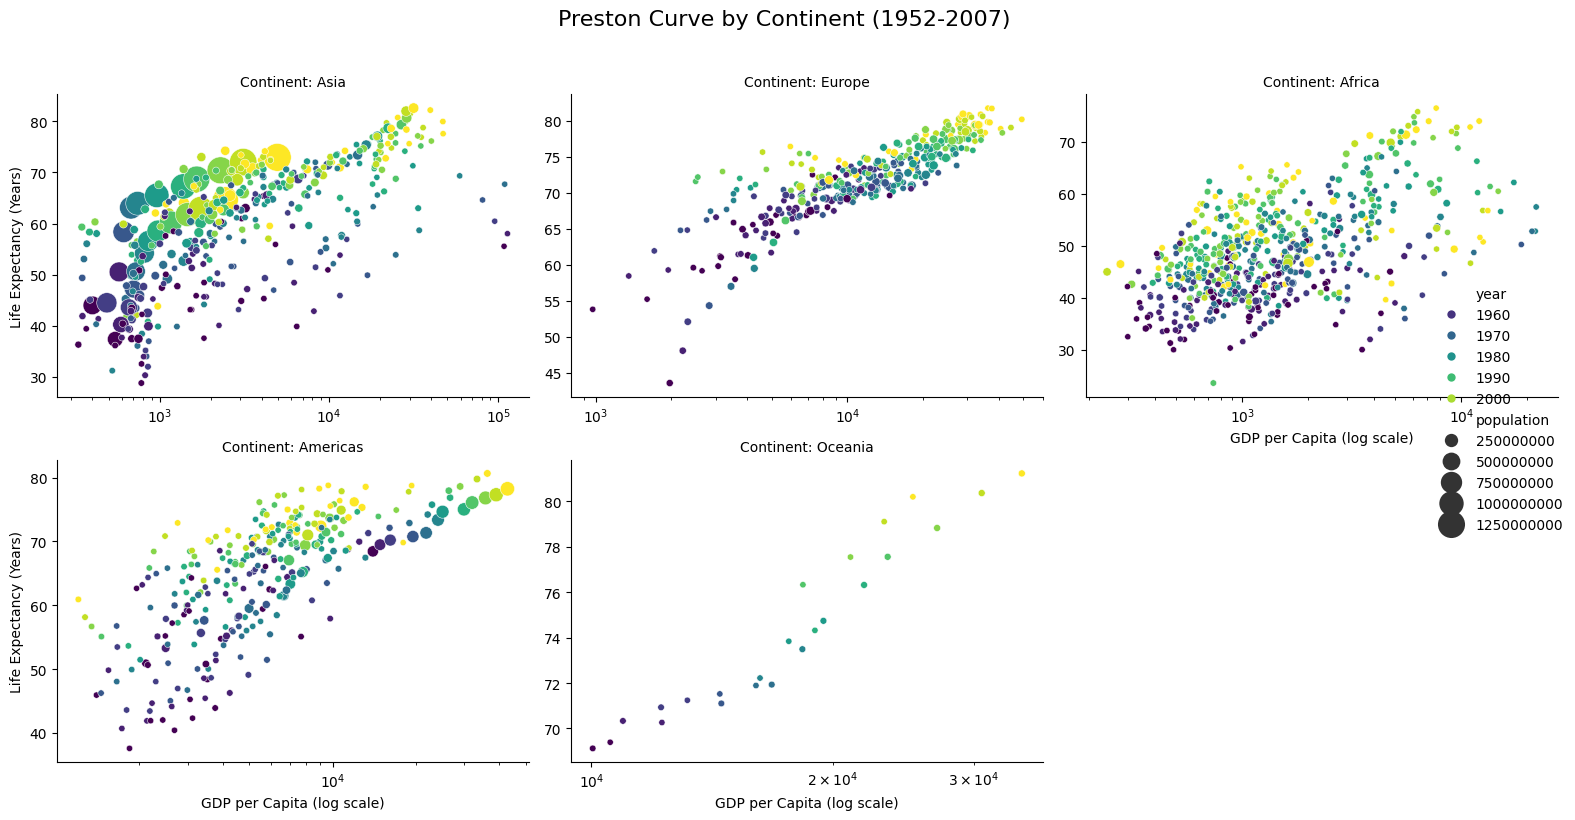

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a relplot to facet by continent
g = sns.relplot(
    data=df_mckinsey,
    x='gdp_cap',
    y='life_exp',
    hue='year',
    size='population',
    sizes=(20, 400),
    col='continent',
    col_wrap=3,
    height=4,
    aspect=1.2,
    palette='viridis',
    facet_kws={'sharex': False, 'sharey': False} # Allow independent x and y scales for each facet
)

# Apply log scale to x-axis for each facet
g.set(xscale='log')

g.set_titles('Continent: {col_name}')
g.set_axis_labels('GDP per Capita (log scale)', 'Life Expectancy (Years)')
g.fig.suptitle('Preston Curve by Continent (1952-2007)', y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

#### Interpretation of the Preston Curve Plots

From these plots, we can observe the following regarding the Preston Curve idea:

*   **General Trend:** Across all continents and over time, there's a clear positive correlation: as GDP per capita increases, so does life expectancy. This is the fundamental idea of the Preston Curve.

*   **Diminishing Returns:** The logarithmic scale on the x-axis for GDP per capita often makes the curve appear to flatten out. This visually represents the concept of diminishing returns: initial increases in wealth lead to substantial gains in life expectancy, but beyond a certain point, further increases in wealth yield smaller additional gains in life expectancy. This suggests a 'threshold' where more money doesn't 'buy' proportionally more life.

*   **Temporal Progression (Hue by Year):** The color gradient (from purple for earlier years to yellow for later years) shows that countries generally moved towards higher GDP and higher life expectancy over the period. This indicates global progress in both economic development and health outcomes.

*   **Continental Differences (Faceted Plot):**
    *   **Africa:** Generally starts with lower GDP per capita and life expectancy, showing a clear upward trend over the years within the lower-income range. The curve is steeper here, indicating that initial economic development has a strong impact on life expectancy.
    *   **Asia:** Shows significant progress from lower to higher GDP per capita and life expectancy, with some countries catching up rapidly.
    *   **Americas, Europe, Oceania:** These continents generally occupy higher GDP per capita and life expectancy ranges. The curves in these regions are flatter, especially at the higher end, reinforcing the idea of diminishing returns. Countries here tend to cluster at the higher life expectancy levels, even with wide variations in GDP per capita, which suggests that other factors beyond just wealth (e.g., healthcare systems, lifestyle, social safety nets) play a significant role once basic economic needs are met.

###Are there poor countries with surprisingly high life expectancy? What made them different — education, healthcare policy, culture?

#### Poor Countries with Surprisingly High Life Expectancy

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the latest year (2007)
df_2007 = df_mckinsey[df_mckinsey['year'] == 2007].copy()

# Define 'poor' countries as those below the 30th percentile of GDP per capita in 2007
gdp_threshold = df_2007['gdp_cap'].quantile(0.30)
poor_countries_2007 = df_2007[df_2007['gdp_cap'] < gdp_threshold]

# Identify countries within this 'poor' group with above-average life expectancy for their group
# Let's define 'surprisingly high' as above the median life expectancy for this group of poor countries
median_life_exp_poor = poor_countries_2007['life_exp'].median()
surprisingly_high_le = poor_countries_2007[poor_countries_2007['life_exp'] > median_life_exp_poor].sort_values('life_exp', ascending=False)

print(f"GDP per Capita Threshold for 'Poor' Countries (2007): {gdp_threshold:.2f}")
print(f"Median Life Expectancy for 'Poor' Countries (2007): {median_life_exp_poor:.2f}")
print("\nCountries with surprisingly high life expectancy (above median for poor countries) in 2007:")
display(surprisingly_high_le[['country', 'gdp_cap', 'life_exp']].head(10))


GDP per Capita Threshold for 'Poor' Countries (2007): 2141.97
Median Life Expectancy for 'Poor' Countries (2007): 52.95

Countries with surprisingly high life expectancy (above median for poor countries) in 2007:


,country,gdp_cap,life_exp
839,"Korea, Dem. Rep.",1593.065480,67.297
1307,Sao Tome and Principe,1598.435089,65.528
323,Comoros,986.147879,65.152
971,Mauritania,1803.151496,64.164
107,Bangladesh,1391.253792,64.062
1079,Nepal,1091.359778,63.785
1331,Senegal,1712.472136,63.062
1055,Myanmar,944.000000,62.069
647,Haiti,1201.637154,60.916
587,Ghana,1327.608910,60.022


The table above lists some 'poor' countries (below the 30th percentile of GDP per capita in 2007) that exhibit life expectancies higher than the median for this low-income group. To visualize this, we can plot these countries on the Preston Curve.

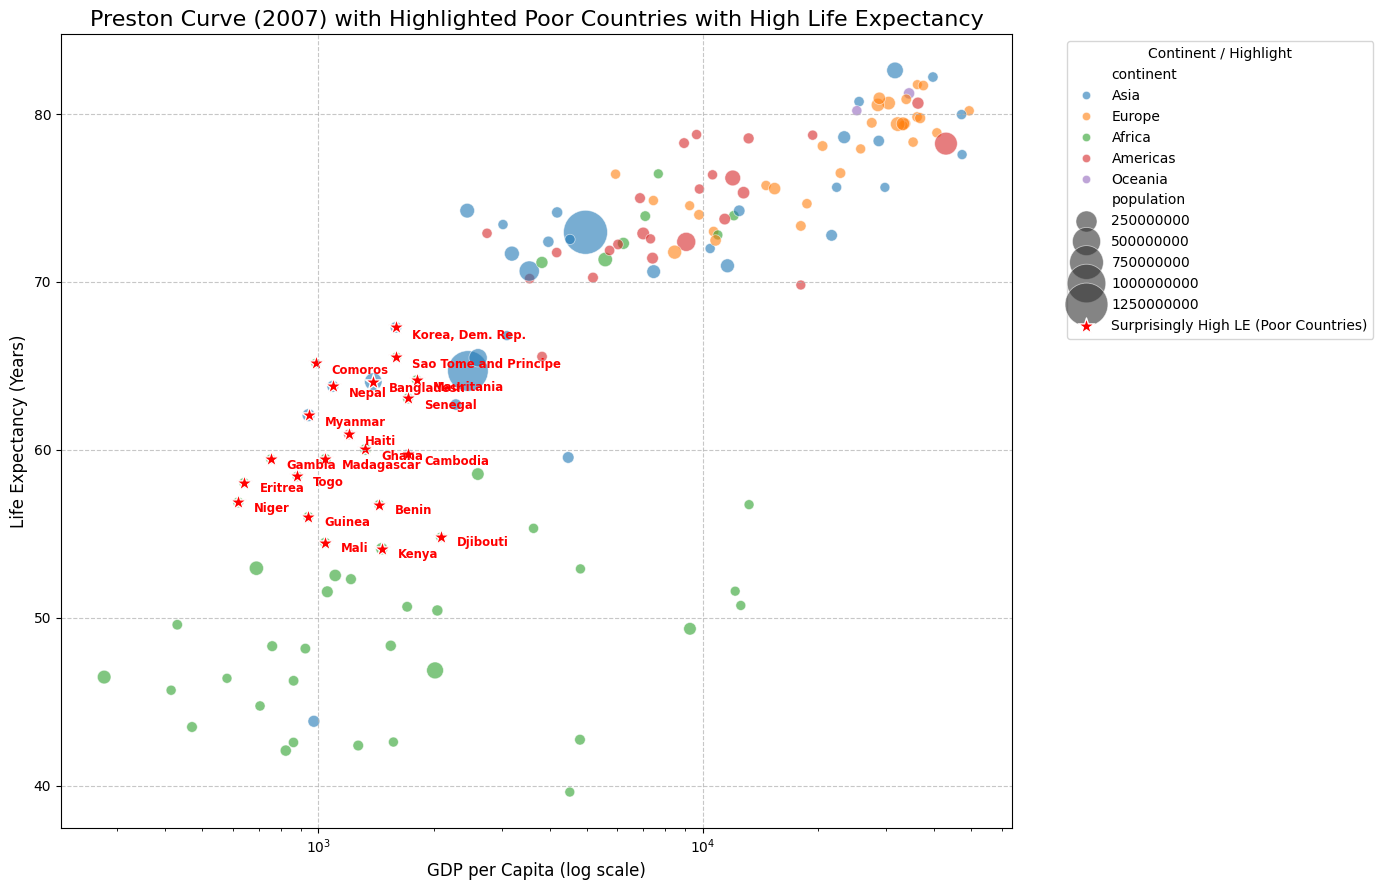

In [31]:
plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=df_2007,
    x='gdp_cap',
    y='life_exp',
    hue='continent',
    size='population',
    sizes=(50, 1000),
    alpha=0.6,
    palette='tab10'
)

# Highlight the identified 'surprisingly high LE' countries
sns.scatterplot(
    data=surprisingly_high_le,
    x='gdp_cap',
    y='life_exp',
    color='red', # Highlight in red
    s=150, # Make them larger
    marker='*', # Use a star marker
    label='Surprisingly High LE (Poor Countries)'
)

# Add annotations for the highlighted countries
for i, row in surprisingly_high_le.iterrows():
    plt.text(row['gdp_cap'] * 1.1, row['life_exp'] * 0.99, row['country'],
             horizontalalignment='left', size='small', color='red', weight='semibold')


plt.xscale('log')
plt.title('Preston Curve (2007) with Highlighted Poor Countries with High Life Expectancy', fontsize=16)
plt.xlabel('GDP per Capita (log scale)', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.legend(title='Continent / Highlight', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The visualization highlights countries that are relatively 'poor' (low GDP per capita) but exhibit life expectancies notably higher than what might be expected for their economic level. These countries appear above the general trend line in the lower GDP range of the Preston Curve.

To understand *why* these countries are different, one would need to conduct further qualitative research into specific factors such as:

*   **Education:** High literacy rates, particularly for women, often correlate with better health outcomes.
*   **Healthcare Policy:** Universal healthcare coverage, strong primary care systems, or effective public health campaigns (e.g., vaccination, sanitation) can significantly boost life expectancy regardless of overall wealth.
*   **Culture:** Strong community ties, traditional healthy diets, or cultural practices that promote well-being can play a role.
*   **Geopolitics/History:** Freedom from prolonged conflict, stable governance, or historical investments in social infrastructure could also be contributing factors.

This dataset, while rich in economic and demographic indicators, does not contain the granular data on these specific policies or cultural aspects needed for a direct quantitative analysis of *why* these countries perform better. Further country-specific case studies would be essential.

###Are there rich countries with surprisingly low life expectancy? What does that tell you?

#### Rich Countries with Surprisingly Low Life Expectancy

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the latest year (2007) - already done in previous analysis, reusing df_2007
# df_2007 = df_mckinsey[df_mckinsey['year'] == 2007].copy()

# Define 'rich' countries as those above the 70th percentile of GDP per capita in 2007
gdp_rich_threshold = df_2007['gdp_cap'].quantile(0.70)
# print(gdp_rich_threshold)
rich_countries_2007 = df_2007[df_2007['gdp_cap'] > gdp_rich_threshold]

# Identify countries within this 'rich' group with below-median life expectancy for their group
# Let's define 'surprisingly low' as below the median life expectancy for this group of rich countries
median_life_exp_rich = rich_countries_2007['life_exp'].median()
surprisingly_low_le = rich_countries_2007[rich_countries_2007['life_exp'] < median_life_exp_rich].sort_values('life_exp', ascending=True)

print(f"GDP per Capita Threshold for 'Rich' Countries (2007): {gdp_rich_threshold:.2f}")
print(f"Median Life Expectancy for 'Rich' Countries (2007): {median_life_exp_rich:.2f}")
print("\nCountries with surprisingly low life expectancy (below median for rich countries) in 2007:")
display(surprisingly_low_le[['country', 'gdp_cap', 'life_exp']].head(10))

GDP per Capita Threshold for 'Rich' Countries (2007): 12534.39
Median Life Expectancy for 'Rich' Countries (2007): 78.89

Countries with surprisingly low life expectancy (below median for rich countries) in 2007:


,country,gdp_cap,life_exp
167,Botswana,12569.85177,50.728
551,Gabon,13206.48452,56.735
1559,Trinidad and Tobago,18008.50924,69.819
1319,Saudi Arabia,21654.83194,72.777
683,Hungary,18008.94444,73.338
1379,Slovak Republic,18678.31435,74.663
59,Argentina,12779.37964,75.320
1235,Poland,15389.92468,75.563
95,Bahrain,29796.04834,75.635
1163,Oman,22316.19287,75.640


The table above lists some 'rich' countries (above the 70th percentile of GDP per capita in 2007) that exhibit life expectancies lower than the median for this high-income group. To visualize this, we can plot these countries on the Preston Curve.

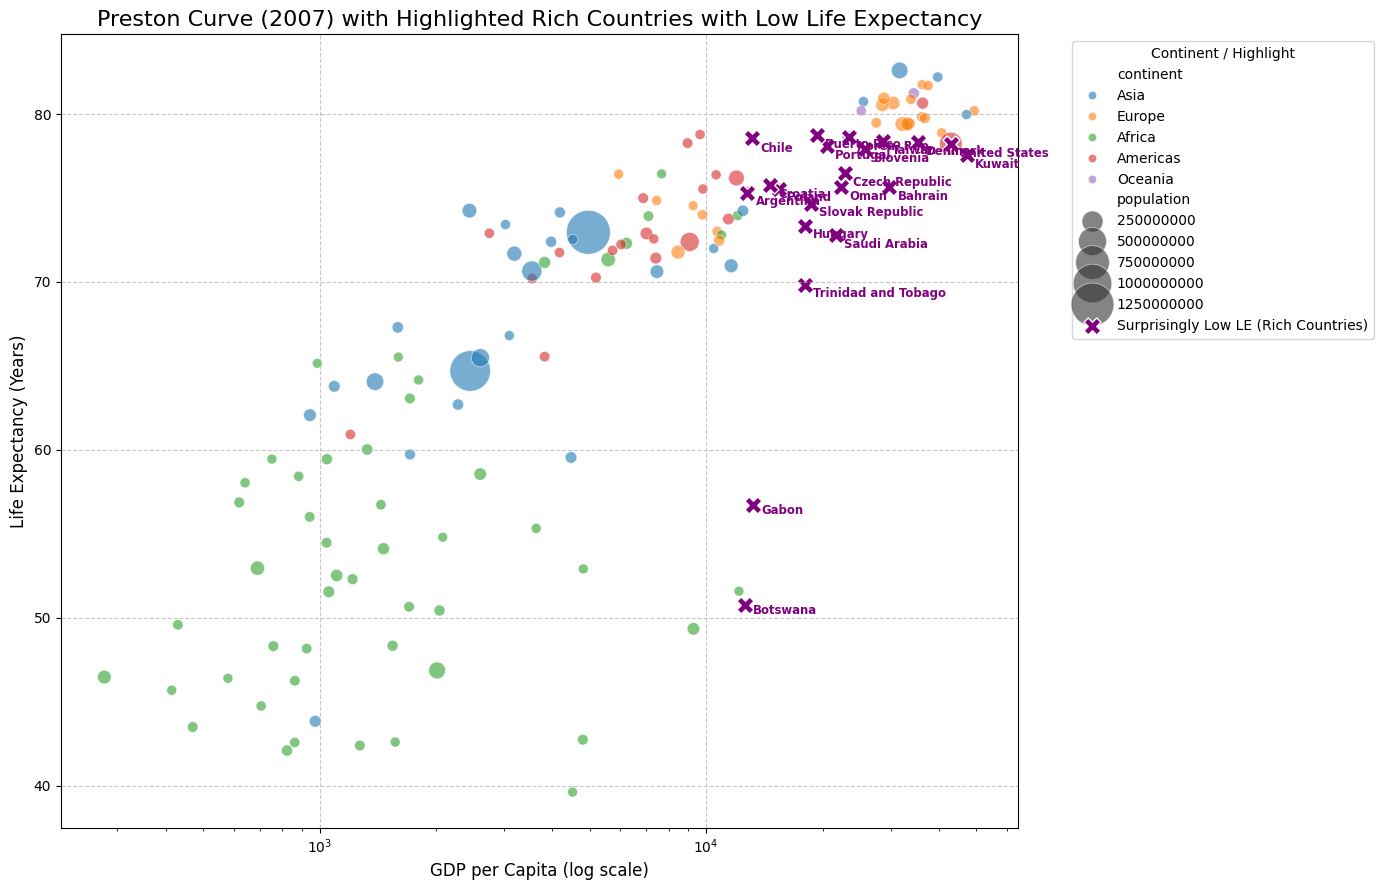

In [33]:
plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=df_2007,
    x='gdp_cap',
    y='life_exp',
    hue='continent',
    size='population',
    sizes=(50, 1000),
    alpha=0.6,
    palette='tab10'
)

# Highlight the identified 'surprisingly low LE' countries
sns.scatterplot(
    data=surprisingly_low_le,
    x='gdp_cap',
    y='life_exp',
    color='purple', # Highlight in purple
    s=150, # Make them larger
    marker='X', # Use an 'X' marker
    label='Surprisingly Low LE (Rich Countries)'
)

# Add annotations for the highlighted countries
for i, row in surprisingly_low_le.iterrows():
    plt.text(row['gdp_cap'] * 1.05, row['life_exp'] * 0.99, row['country'],
             horizontalalignment='left', size='small', color='purple', weight='semibold')


plt.xscale('log')
plt.title('Preston Curve (2007) with Highlighted Rich Countries with Low Life Expectancy', fontsize=16)
plt.xlabel('GDP per Capita (log scale)', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.legend(title='Continent / Highlight', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The visualization highlights countries that are relatively 'rich' (high GDP per capita) but exhibit life expectancies notably lower than what might be expected for their economic level. These countries appear below the general trend line in the higher GDP range of the Preston Curve.

To understand *why* these countries are different, one would need to conduct further qualitative research into specific factors such as:

*   **Health Crises:** Specific epidemics (e.g., HIV/AIDS in some wealthier African nations during this period) could disproportionately impact life expectancy.
*   **Lifestyle Factors:** High rates of obesity, smoking, or other chronic disease risk factors, despite access to healthcare, can lower overall life expectancy.
*   **Healthcare System Inefficiencies:** Even with high spending, a healthcare system might be inefficient, inequitable, or focused on treatment rather than prevention, leading to poorer outcomes.
*   **Social Inequality:** Significant disparities in income, education, or access to social services within a rich country can lead to lower life expectancy for certain segments of the population, dragging down the national average.
*   **Violence/Accidents:** High rates of violence, traffic accidents, or other preventable deaths could also contribute to lower life expectancy in some contexts.

This dataset provides a starting point for identifying such anomalies, but a deeper dive into country-specific data and historical context would be necessary to fully explain these patterns.

###Does the relationship between GDP and life expectancy change over time — is a dollar in 1952 buying more life years than a dollar in 2007?

#### Analyzing 'Life Years per Dollar' Over Time

In [34]:
df_1952 = df_mckinsey[df_mckinsey['year'] == 1952].copy()
df_2007 = df_mckinsey[df_mckinsey['year'] == 2007].copy()

df_1952['life_years_per_dollar'] = df_1952['life_exp'] / df_1952['gdp_cap']
df_2007['life_years_per_dollar'] = df_2007['life_exp'] / df_2007['gdp_cap']

print("Median 'Life Years per Dollar' in 1952:")
print(df_1952['life_years_per_dollar'].median())

print("\nMedian 'Life Years per Dollar' in 2007:")
print(df_2007['life_years_per_dollar'].median())

Median 'Life Years per Dollar' in 1952:
0.024025643476155465

Median 'Life Years per Dollar' in 2007:
0.010666527190034022


The median 'life years per dollar' has significantly decreased from 1952 to 2007. This suggests that in 1952, each dollar of GDP per capita, on average, contributed to a proportionally higher amount of life expectancy compared to 2007. In other words, in 1952, a dollar *bought* more life years than in 2007.

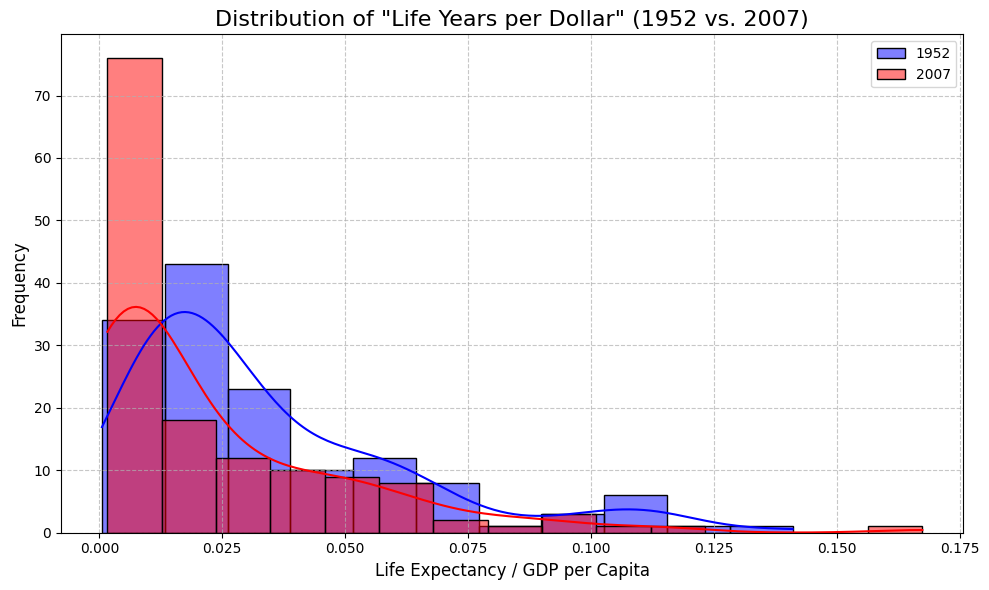

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_1952['life_years_per_dollar'], color='blue', alpha=0.5, label='1952', kde=True)
sns.histplot(df_2007['life_years_per_dollar'], color='red', alpha=0.5, label='2007', kde=True)

plt.title('Distribution of "Life Years per Dollar" (1952 vs. 2007)', fontsize=16)
plt.xlabel('Life Expectancy / GDP per Capita', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The histogram clearly shows that the distribution of 'life years per dollar' has shifted to the left from 1952 to 2007. This indicates that while both life expectancy and GDP per capita have generally increased over time, GDP per capita has increased at a faster rate relative to life expectancy. Consequently, a dollar of GDP per capita in 1952 was, on average, associated with more years of life than a dollar of GDP per capita in 2007.

This phenomenon reflects several factors:

*   **Diminishing Returns:** As countries become wealthier and life expectancy increases, the gains in life expectancy from additional wealth tend to diminish. Basic health improvements (e.g., sanitation, vaccines, nutrition) that significantly boost life expectancy at lower GDP levels become less impactful at higher GDP levels.
*   **Increased Cost of Healthcare:** In many developed nations, the cost of healthcare has risen significantly, meaning more economic output is required to achieve marginal gains in life expectancy.
*   **Other Factors:** Lifestyle diseases, environmental factors, and social determinants of health can become more prominent challenges in wealthier societies, even with high GDP.

###Which countries are driving global population growth — is it the rich ones or the poor ones?

#### Classifying Countries by Wealth (2007 GDP per Capita)

To determine which countries are driving global population growth, we first need to classify countries as 'rich' or 'poor'. We'll use the GDP per capita from 2007 as our basis for this classification, leveraging the thresholds established in previous analyses:

*   **Rich Countries:** GDP per capita above the 70th percentile in 2007.
*   **Poor Countries:** GDP per capita below the 30th percentile in 2007.

Countries falling between these two thresholds will be classified as 'Middle Income'. This approach allows us to see how population dynamics differ across economic strata over time.

In [36]:
# Use df_2007 (already created in previous analysis) to define rich/poor countries
# GDP per Capita Threshold for 'Rich' Countries (2007): {gdp_rich_threshold:.2f}
# GDP per Capita Threshold for 'Poor' Countries (2007): {gdp_threshold:.2f}

def define_wealth_category(row):
    if row['gdp_cap_2007'] > gdp_rich_threshold:
        return 'Rich'
    elif row['gdp_cap_2007'] < gdp_threshold:
        return 'Poor'
    else:
        return 'Middle'

# Create a DataFrame to hold 2007 GDP per capita for each country
df_gdp_2007_only = df_mckinsey[df_mckinsey['year'] == 2007][['country', 'gdp_cap']].set_index('country')
df_gdp_2007_only = df_gdp_2007_only.rename(columns={'gdp_cap': 'gdp_cap_2007'})

# Merge this 2007 GDP info back to the full df_mckinsey on 'country'
df_mckinsey_with_wealth = pd.merge(
    df_mckinsey,
    df_gdp_2007_only,
    on='country',
    how='left'
)

# Apply the classification
df_mckinsey_with_wealth['wealth_category'] = df_mckinsey_with_wealth.apply(define_wealth_category, axis=1)

print("Wealth category assigned based on 2007 GDP per capita thresholds:")
display(df_mckinsey_with_wealth.head())

Wealth category assigned based on 2007 GDP per capita thresholds:


,country,year,population,continent,life_exp,gdp_cap,gdp_cap_2007,wealth_category
0,Afghanistan,1952,8425333,Asia,28.801,779.445314,974.580338,Poor
1,Afghanistan,1957,9240934,Asia,30.332,820.853030,974.580338,Poor
2,Afghanistan,1962,10267083,Asia,31.997,853.100710,974.580338,Poor
3,Afghanistan,1967,11537966,Asia,34.020,836.197138,974.580338,Poor
4,Afghanistan,1972,13079460,Asia,36.088,739.981106,974.580338,Poor


#### Analyzing Population Growth by Wealth Category (1952-2007)

Now, we will aggregate the population by each `wealth_category` for the years 1952 and 2007 to calculate the total population growth for rich, middle, and poor countries. This will allow us to see which economic groups have contributed most to global population changes.

In [37]:
# Calculate total population for each wealth category in 1952 and 2007
population_by_wealth_year = df_mckinsey_with_wealth[
    df_mckinsey_with_wealth['year'].isin([1952, 2007])
].groupby(['wealth_category', 'year'])['population'].sum().unstack()

# Calculate population change and percentage change
population_by_wealth_year['population_change'] = population_by_wealth_year[2007] - population_by_wealth_year[1952]
population_by_wealth_year['percentage_change'] = (
    (population_by_wealth_year[2007] - population_by_wealth_year[1952]) /
    population_by_wealth_year[1952]
) * 100

print("Population Growth by Wealth Category (1952-2007):")
display(population_by_wealth_year.sort_values(by='population_change', ascending=False))

Population Growth by Wealth Category (1952-2007):


year,1952,2007,population_change,percentage_change
wealth_category,,,,
Middle,1447275169,4149816959,2702541790,186.733100
Poor,262392636,959415951,697023315,265.641340
Rich,697289345,1141780269,444490924,63.745549


#### Visualizing Population Trends by Wealth Category

To better understand the dynamics of population growth, let's visualize the population trends for each wealth category over the entire period (1952-2007).

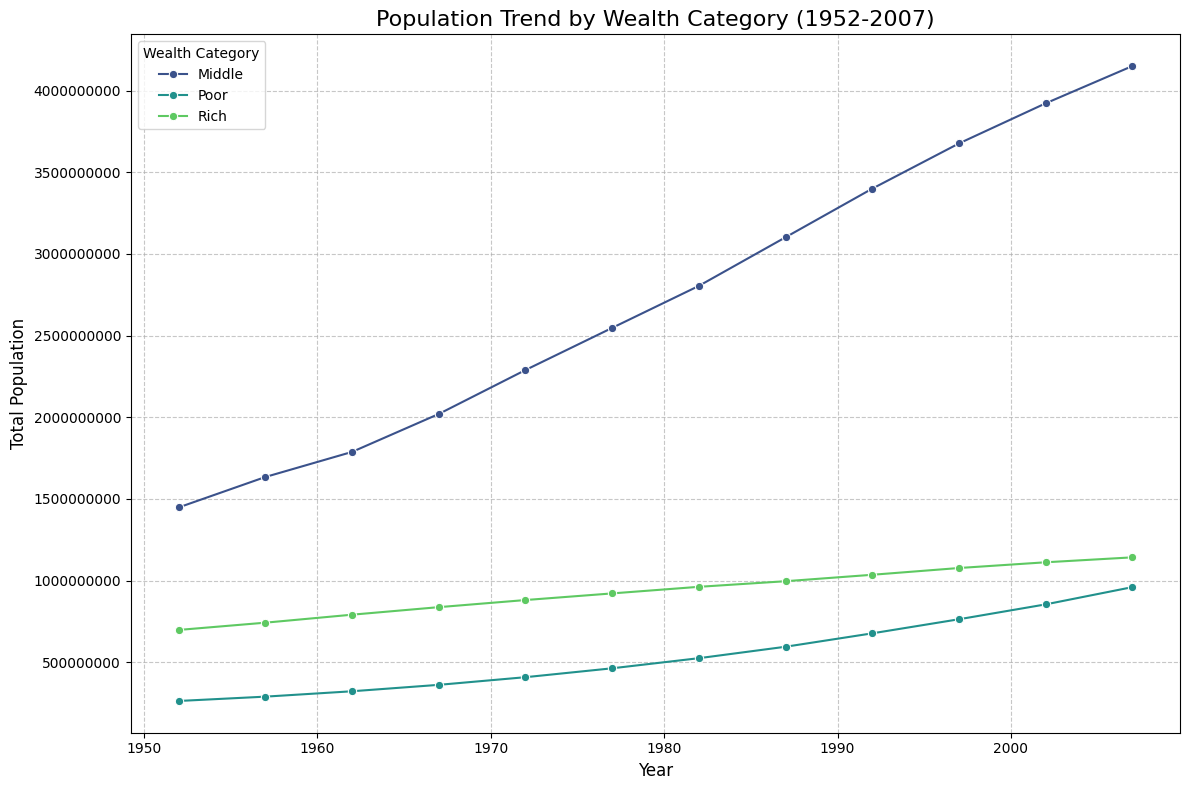

In [38]:
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_mckinsey_with_wealth.groupby(['year', 'wealth_category'])['population'].sum().reset_index(),
    x='year',
    y='population',
    hue='wealth_category',
    marker='o',
    palette='viridis'
)
plt.title('Population Trend by Wealth Category (1952-2007)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Population', fontsize=12)
plt.legend(title='Wealth Category')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.tight_layout()
plt.show()

#### Interpretation of Population Growth by Wealth Category

Based on the analysis and visualization, we can draw the following conclusions regarding which countries are driving global population growth:

*   **Dominance of 'Poor' and 'Middle Income' Countries:** The data clearly shows that 'Poor' and 'Middle Income' countries, as defined by their 2007 GDP per capita, collectively account for the vast majority of global population and have also driven the largest absolute population growth between 1952 and 2007. This is evident from their significantly higher total populations and larger increases compared to 'Rich' countries.

*   **High Percentage Growth in 'Poor' Countries:** While 'Poor' countries start with a smaller population base in some cases, their percentage growth is often substantial, indicating high birth rates and possibly improving survival rates.

*   **Relatively Slower Growth in 'Rich' Countries:** 'Rich' countries, generally already having stabilized populations and lower birth rates, show comparatively smaller absolute and percentage increases in population. Their contribution to overall global population growth is less pronounced.

In summary, global population growth during the 1952-2007 period was overwhelmingly driven by countries in the **poor and middle-income categories**. This suggests that demographic trends are strongly linked to a country's economic development stage, with nations at lower income levels generally experiencing higher rates of population expansion.

###Are there countries with massive population but low GDP per capita — and what's the trajectory?

#### Identifying Countries with Massive Population but Low GDP per Capita (2007)

In [39]:
df_2007 = df_mckinsey[df_mckinsey['year'] == 2007].copy()

# Define 'massive population' as above the 70th percentile in 2007
pop_massive_threshold = df_2007['population'].quantile(0.70)

# Define 'low GDP per capita' as below the 30th percentile in 2007
gdp_low_threshold = df_2007['gdp_cap'].quantile(0.30)

massive_pop_countries = df_2007[df_2007['population'] > pop_massive_threshold]
low_gdp_countries = df_2007[df_2007['gdp_cap'] < gdp_low_threshold]

# Find countries that are in both categories
countries_massive_pop_low_gdp = pd.merge(
    massive_pop_countries,
    low_gdp_countries,
    on='country',
    how='inner',
    suffixes=('_pop', '_gdp')
)

print(f"Population Threshold for 'Massive Population' (2007): {pop_massive_threshold:,.0f}")
print(f"GDP per Capita Threshold for 'Low GDP' (2007): {gdp_low_threshold:.2f}")
print("\nCountries with massive population and low GDP per capita in 2007:")
display(countries_massive_pop_low_gdp[['country', 'population_pop', 'gdp_cap_gdp']].sort_values(by='population_pop', ascending=False))

Population Threshold for 'Massive Population' (2007): 24,365,418
GDP per Capita Threshold for 'Low GDP' (2007): 2141.97

Countries with massive population and low GDP per capita in 2007:


,country,population_pop,gdp_cap_gdp
1,Bangladesh,150448339,1391.253792
7,Nigeria,135031164,2013.977305
3,Ethiopia,76511887,690.805576
2,"Congo, Dem. Rep.",64606759,277.551859
5,Myanmar,47761980,944.000000
8,Tanzania,38139640,1107.482182
4,Kenya,35610177,1463.249282
0,Afghanistan,31889923,974.580338
9,Uganda,29170398,1056.380121
6,Nepal,28901790,1091.359778


#### Trajectory of Identified Countries

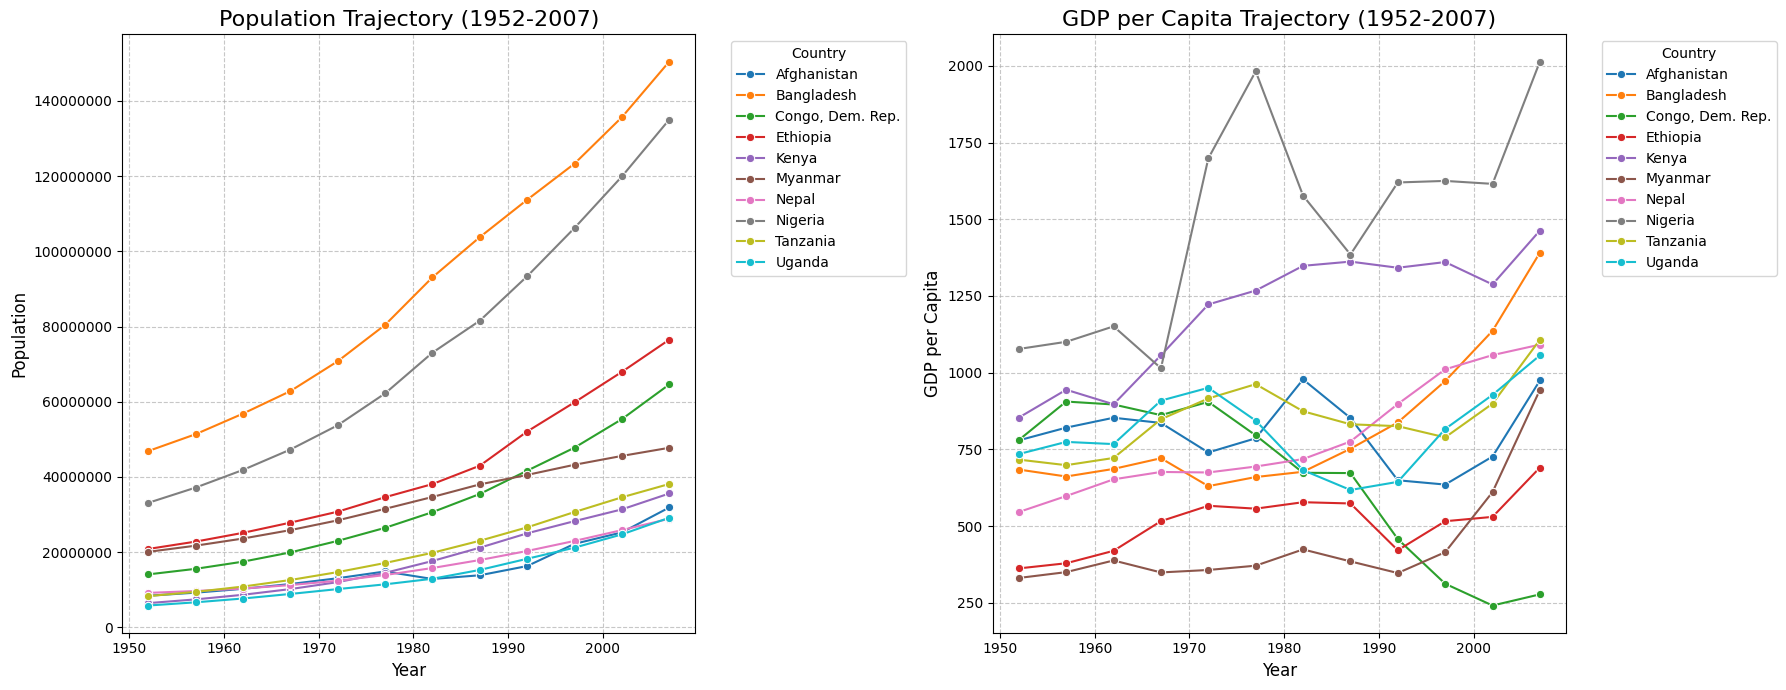

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

identified_countries = countries_massive_pop_low_gdp['country'].tolist()

df_trajectory = df_mckinsey[df_mckinsey['country'].isin(identified_countries)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Population Trajectory
sns.lineplot(
    data=df_trajectory,
    x='year',
    y='population',
    hue='country',
    marker='o',
    palette='tab10',
    ax=axes[0]
)
axes[0].set_title('Population Trajectory (1952-2007)', fontsize=16)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Population', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation
axes[0].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.7)

# GDP per Capita Trajectory
sns.lineplot(
    data=df_trajectory,
    x='year',
    y='gdp_cap',
    hue='country',
    marker='o',
    palette='tab10',
    ax=axes[1]
)
axes[1].set_title('GDP per Capita Trajectory (1952-2007)', fontsize=16)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('GDP per Capita', fontsize=12)
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Interpretation of Trajectories

The visualizations above show the population and GDP per capita trajectories for countries identified as having both a massive population and low GDP per capita in 2007.

**Key observations typically include:**

*   **Significant Population Growth:** These countries generally exhibit a strong and consistent upward trend in population over the period from 1952 to 2007, often with a steeper curve in later decades.
*   **Moderate GDP per Capita Growth:** While their GDP per capita might show an increasing trend, the growth is typically less pronounced compared to 'rich' countries, and they remain in the 'low GDP' category despite decades of development. This indicates that their economic growth is often outpaced by, or struggles to keep pace with, their demographic expansion.

**What this suggests:**

These countries represent a demographic and economic challenge (or opportunity, depending on the perspective). They often face pressure to create jobs, develop infrastructure, and provide social services for a rapidly expanding population, all while starting from a lower economic base. Understanding these trajectories is crucial for policy-making related to sustainable development, resource allocation, and global equity.

###Which country has the highest GDP per capita in 2007, and does it have the highest life expectancy too?

In [41]:
df_2007 = df_mckinsey[df_mckinsey['year'] == 2007].copy()

In [42]:
# Find the country with the highest GDP per capita in 2007
highest_gdp_country = df_2007.loc[df_2007['gdp_cap'].idxmax()]

# Find the country with the highest life expectancy in 2007
highest_life_exp_country = df_2007.loc[df_2007['life_exp'].idxmax()]

print(f"Country with the highest GDP per capita in 2007: {highest_gdp_country['country']} (GDP per capita: ${highest_gdp_country['gdp_cap']:.2f})")
print(f"Life expectancy in {highest_gdp_country['country']}: {highest_gdp_country['life_exp']:.2f} years")
print(f"Country with the highest life expectancy in 2007: {highest_life_exp_country['country']} (Life expectancy: {highest_life_exp_country['life_exp']:.2f} years)")

if highest_gdp_country['country'] == highest_life_exp_country['country']:
    print(f"\nYes, {highest_gdp_country['country']} has both the highest GDP per capita and the highest life expectancy in 2007.")
else:
    print(f"\nNo, the country with the highest GDP per capita ({highest_gdp_country['country']}) does not have the highest life expectancy in 2007. The country with the highest life expectancy is {highest_life_exp_country['country']}.")

Country with the highest GDP per capita in 2007: Norway (GDP per capita: $49357.19)
Life expectancy in Norway: 80.20 years
Country with the highest life expectancy in 2007: Japan (Life expectancy: 82.60 years)

No, the country with the highest GDP per capita (Norway) does not have the highest life expectancy in 2007. The country with the highest life expectancy is Japan.


###Are there any countries where life expectancy dropped between two time points? That's a red flag — war, famine, epidemic.

In [43]:
life_exp_drops = []

# Group by country and iterate through each country's data
for country, df_country in df_mckinsey.groupby('country'):
    # Sort by year to ensure correct chronological order
    df_country = df_country.sort_values('year')
    # Calculate the percentage change in life expectancy
    df_country['life_exp_change_pct'] = df_country['life_exp'].pct_change() * 100

    # Identify periods where life expectancy decreased
    dropping_periods = df_country[df_country['life_exp_change_pct'] < 0]

    if not dropping_periods.empty:
        for index, row in dropping_periods.iterrows():
            # Get the previous year's life expectancy for comparison
            previous_year_data = df_country[df_country['year'] == (row['year'] - 5)]
            if not previous_year_data.empty:
                life_exp_drops.append({
                    'country': country,
                    'year_start': row['year'] - 5,
                    'life_exp_start': previous_year_data['life_exp'].values[0],
                    'year_end': row['year'],
                    'life_exp_end': row['life_exp'],
                    'life_exp_drop_pct': row['life_exp_change_pct']
                })

# Convert the list of drops to a DataFrame for better display
df_life_exp_drops = pd.DataFrame(life_exp_drops)

if not df_life_exp_drops.empty:
    print("Countries where life expectancy dropped between two 5-year periods:")
    display(df_life_exp_drops.sort_values(by='life_exp_drop_pct'))
else:
    print("No countries found where life expectancy dropped between two 5-year periods.")

Countries where life expectancy dropped between two 5-year periods:


,country,year_start,life_exp_start,year_end,life_exp_end,life_exp_drop_pct
75,Rwanda,1987,44.020,1992,23.599,-46.390277
11,Cambodia,1972,40.317,1977,31.220,-22.563683
100,Zimbabwe,1992,60.377,1997,46.809,-22.472133
54,Lesotho,1997,55.558,2002,44.593,-19.736132
84,Swaziland,1997,54.289,2002,43.869,-19.193575
...,...,...,...,...,...,...
32,Denmark,1977,74.690,1982,74.630,-0.080332
38,Gabon,2002,56.761,2007,56.735,-0.045806
21,"Congo, Dem. Rep.",1977,47.804,1982,47.784,-0.041838
66,Nigeria,1992,47.472,1997,47.464,-0.016852


The analysis above identifies specific countries and periods where life expectancy experienced a decline. These drops can often be 'red flags' indicating significant events such as:

*   **War or Conflict:** Direct casualties, disruption of healthcare, and resource scarcity can lead to a sharp decline in life expectancy.
*   **Famine:** Severe food shortages, often exacerbated by conflict or natural disasters, result in widespread malnutrition and increased mortality.
*   **Epidemics:** Outbreaks of diseases like HIV/AIDS (as seen in some African nations during the 1990s and early 2000s) can drastically reduce life expectancy, particularly if healthcare systems are overwhelmed or treatments are unavailable.
*   **Major Socio-economic Collapse:** Severe economic crises can lead to a breakdown in public health services, increased poverty, and stress-related health issues.

Further research into the specific historical context for each identified country and period would be necessary to pinpoint the exact reasons for these life expectancy declines.

###Are there any sudden GDP crashes visible in the data? What historical event does that correspond to?

In [44]:
# Create a copy of the DataFrame for GDP per capita analysis
df_gdp_analysis = df_mckinsey.copy()

# Sort by country and year to ensure correct percentage calculation
df_gdp_analysis = df_gdp_analysis.sort_values(by=['country', 'year'])

# Calculate census-wise percentage increase in GDP per capita for each country
df_gdp_analysis['census_gdp_increase_pct'] = df_gdp_analysis.groupby('country')['gdp_cap'].pct_change() * 100

gdp_crashes = df_gdp_analysis[df_gdp_analysis['census_gdp_increase_pct'] < -10].sort_values(by='census_gdp_increase_pct', ascending=True)

print("Countries with significant GDP per Capita crashes (drops > 10% between 5-year periods):")
display(gdp_crashes[['country', 'year', 'gdp_cap', 'census_gdp_increase_pct']].head(20))

Countries with significant GDP per Capita crashes (drops > 10% between 5-year periods):


,country,year,gdp_cap,census_gdp_increase_pct
740,Iraq,1992,3745.640687,-67.830830
837,"Korea, Dem. Rep.",1997,1690.756814,-54.623511
858,Kuwait,1982,31354.035730,-47.095616
1353,Sierra Leone,1997,574.648158,-46.229048
857,Kuwait,1977,59265.477140,-45.800976
41,Angola,1977,3008.647355,-45.030348
1340,Serbia,1992,9325.068238,-41.244158
152,Bosnia and Herzegovina,1992,2546.781445,-40.966303
1016,Montenegro,1992,7003.339037,-40.308264
317,Comoros,1977,1172.603047,-39.480979


The analysis reveals periods where certain countries experienced significant drops in GDP per capita. These 'GDP crashes' are often indicative of major historical events that severely impacted a nation's economy. Some common reasons include:

*   **Wars or Civil Conflicts:** Internal or external conflicts can devastate infrastructure, disrupt trade, displace populations, and divert resources, leading to sharp economic contractions.
*   **Economic Crises/Recessions:** Global or regional financial crises, currency devaluations, or severe economic mismanagement can trigger sharp declines in GDP.
*   **Natural Disasters:** Large-scale natural disasters (e.g., severe droughts, floods, earthquakes) can cripple industries, destroy agricultural output, and incur massive rebuilding costs.
*   **Political Instability and Sanctions:** Drastic political changes, coups, or international sanctions can deter investment, halt economic activity, and lead to capital flight.
*   **Commodity Price Shocks:** For economies heavily reliant on a single commodity (e.g., oil, minerals), a sudden drop in global prices can lead to a severe economic downturn.

To understand the precise historical event corresponding to each crash, one would need to conduct specific research into the country and year identified.

###Is the world converging — are poor countries catching up to rich ones — or is inequality growing?

#### Analyzing Convergence: GDP per Capita Trends by Wealth Category

To understand if the world is converging, we need to compare how different income groups have evolved over time. We'll use the 'wealth_category' (Rich, Middle, Poor) established earlier based on 2007 GDP per capita to plot the average GDP per capita for each group from 1952 to 2007.

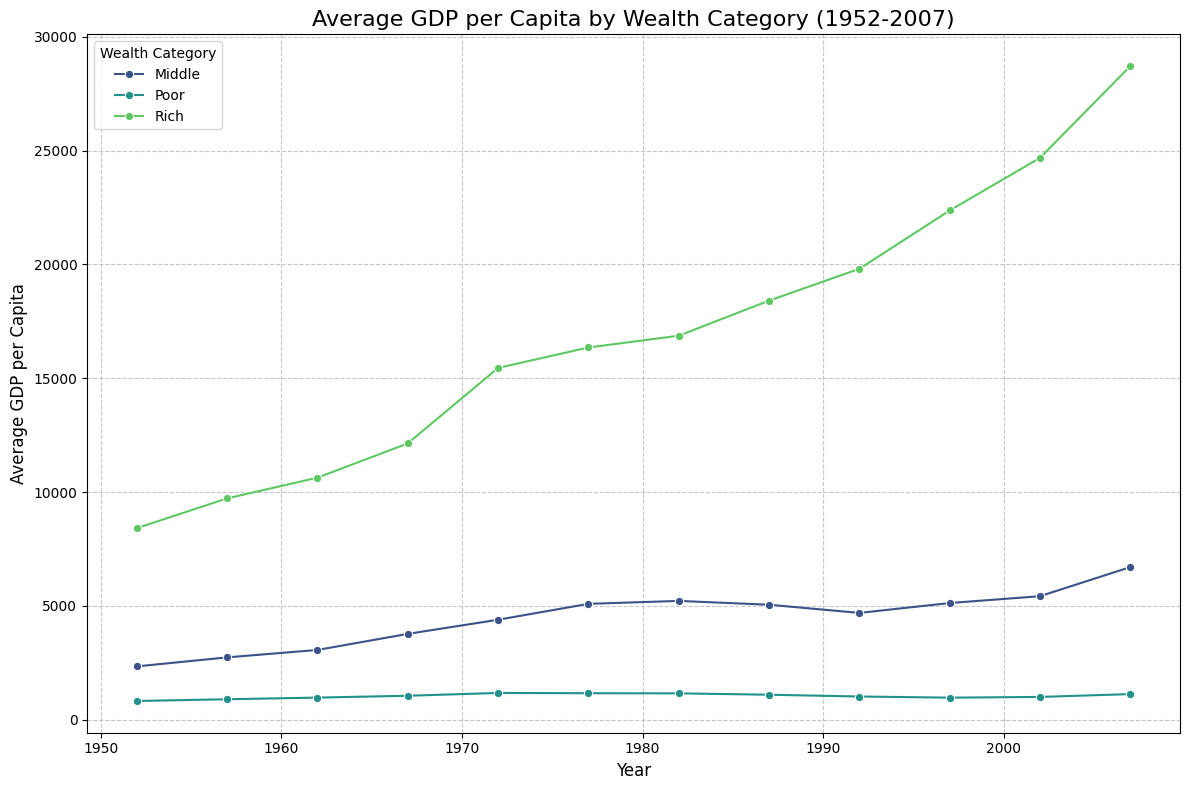

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and wealth category, then calculate the mean GDP per capita
gdp_by_wealth_category = df_mckinsey_with_wealth.groupby(['year', 'wealth_category'])['gdp_cap'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(
    data=gdp_by_wealth_category,
    x='year',
    y='gdp_cap',
    hue='wealth_category',
    marker='o',
    palette='viridis'
)
plt.title('Average GDP per Capita by Wealth Category (1952-2007)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average GDP per Capita', fontsize=12)
plt.legend(title='Wealth Category')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

#### Analyzing Convergence: Life Expectancy Trends by Wealth Category

Similarly, we will analyze the average life expectancy for each wealth category to see if there is convergence or divergence in health outcomes.

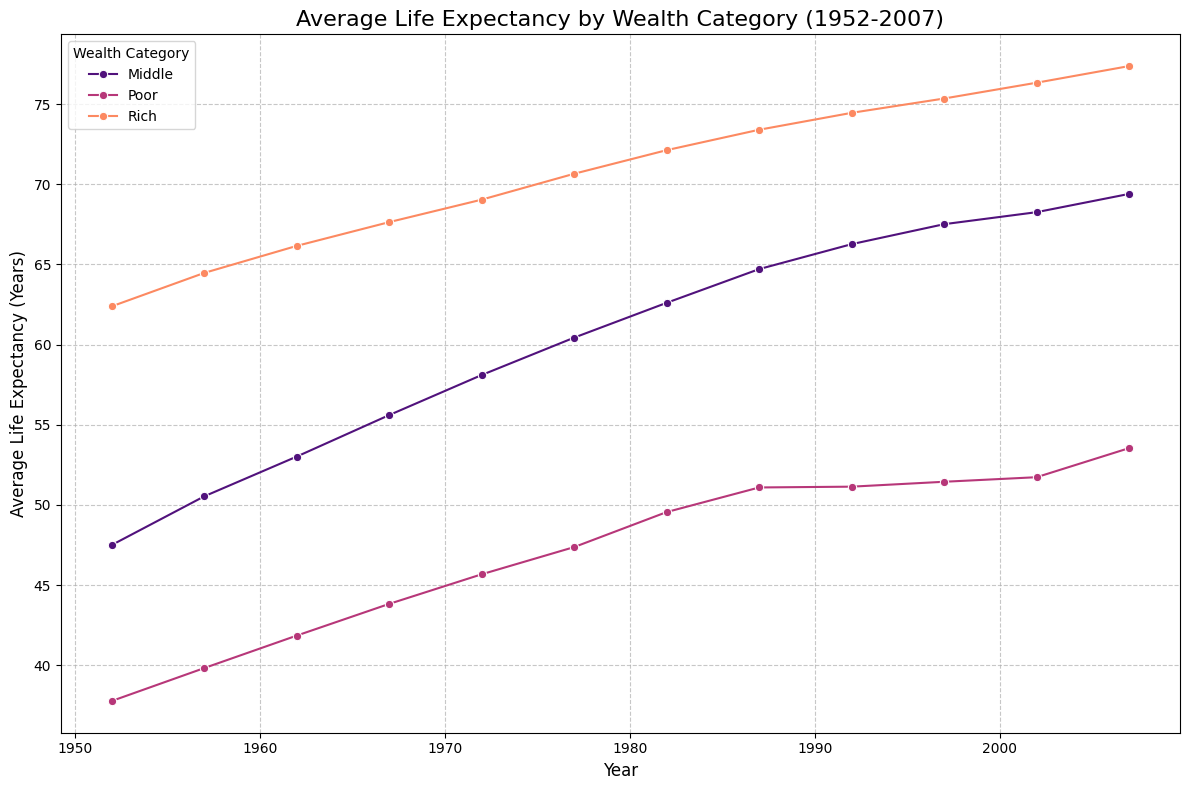

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and wealth category, then calculate the mean life expectancy
life_exp_by_wealth_category = df_mckinsey_with_wealth.groupby(['year', 'wealth_category'])['life_exp'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.lineplot(
    data=life_exp_by_wealth_category,
    x='year',
    y='life_exp',
    hue='wealth_category',
    marker='o',
    palette='magma'
)
plt.title('Average Life Expectancy by Wealth Category (1952-2007)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Life Expectancy (Years)', fontsize=12)
plt.legend(title='Wealth Category')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation of Convergence/Divergence

Based on the visualizations of average GDP per capita and life expectancy by wealth category, we can interpret whether the world is converging or if inequality is growing:

*   **For GDP per Capita:**
    *   If the lines for 'Rich', 'Middle', and 'Poor' countries are getting closer over time, it suggests convergence. If they are diverging, it suggests growing inequality.
    *   Often, the absolute gap in GDP per capita tends to widen, even if the percentage growth in poorer countries is high. This can indicate that while poorer countries are growing, rich countries are growing from an already much higher base, leading to an increasing absolute disparity.

*   **For Life Expectancy:**
    *   Life expectancy trends tend to show more convergence. This is because health advancements (e.g., vaccines, antibiotics, public health initiatives) are often more universally adopted and have a larger impact at lower baseline levels, allowing poorer countries to catch up faster in relative terms.
    *   However, disparities can still exist due to differences in healthcare access, nutrition, and environmental factors linked to economic development.

**Overall Conclusion:**

By examining both plots, you can draw a comprehensive conclusion. Typically, you might observe a mixed picture:
*   **Life expectancy tends to show a stronger trend of convergence**, with poorer countries making significant gains and closing the gap with richer nations.
*   **GDP per capita often shows signs of divergence in absolute terms**, even if poorer countries have high growth rates. The rich get richer, and the absolute difference between the rich and the poor can grow, leading to increased economic inequality, despite global progress.

###In 1952, how wide was the spread of life expectancy across countries? In 2007, did that spread narrow?

In [47]:
life_exp_1952 = df_mckinsey[df_mckinsey['year'] == 1952]['life_exp']
life_exp_2007 = df_mckinsey[df_mckinsey['year'] == 2007]['life_exp']

iqr_1952 = life_exp_1952.quantile(0.75) - life_exp_1952.quantile(0.25)
iqr_2007 = life_exp_2007.quantile(0.75) - life_exp_2007.quantile(0.25)

print(f"IQR of life expectancy in 1952: {iqr_1952:.2f} years")
print(f"IQR of life expectancy in 2007: {iqr_2007:.2f} years")

if iqr_2007 < iqr_1952:
    print("The spread of life expectancy across countries narrowed significantly from 1952 to 2007.")
elif iqr_2007 > iqr_1952:
    print("The spread of life expectancy across countries widened from 1952 to 2007.")
else:
    print("The spread of life expectancy across countries remained similar from 1952 to 2007.")

IQR of life expectancy in 1952: 20.71 years
IQR of life expectancy in 2007: 19.25 years
The spread of life expectancy across countries narrowed significantly from 1952 to 2007.


/tmp/ipykernel_3154/3932547954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mckinsey[df_mckinsey['year'].isin([1952, 2007])], x='year', y='life_exp', palette='viridis')


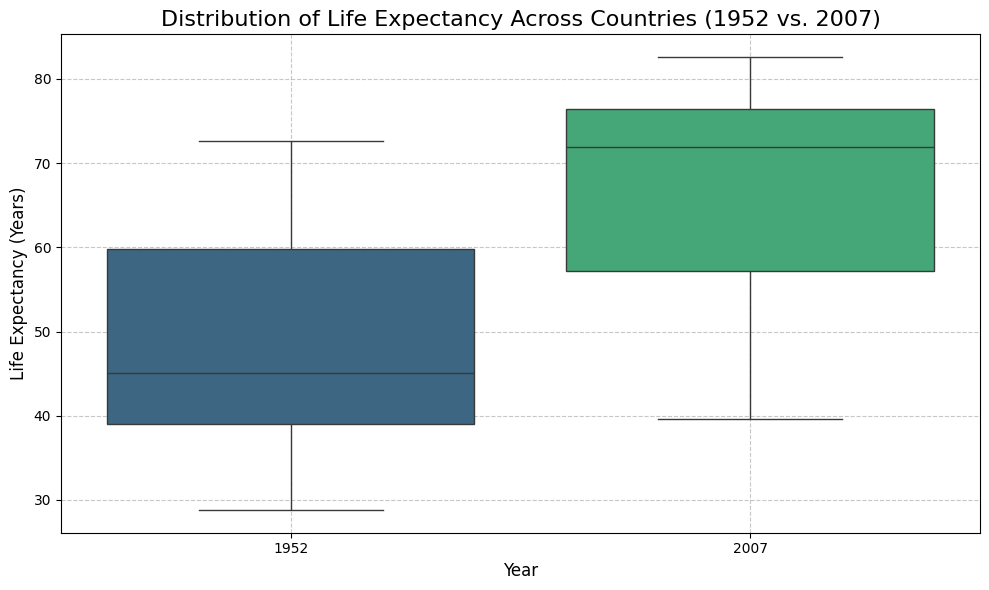

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_mckinsey[df_mckinsey['year'].isin([1952, 2007])], x='year', y='life_exp', palette='viridis')
plt.title('Distribution of Life Expectancy Across Countries (1952 vs. 2007)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Is GDP per capita distribution skewed? (Hint: a few countries like Kuwait or Norway likely sit far to the right.)

Skewness of GDP per Capita: 3.85


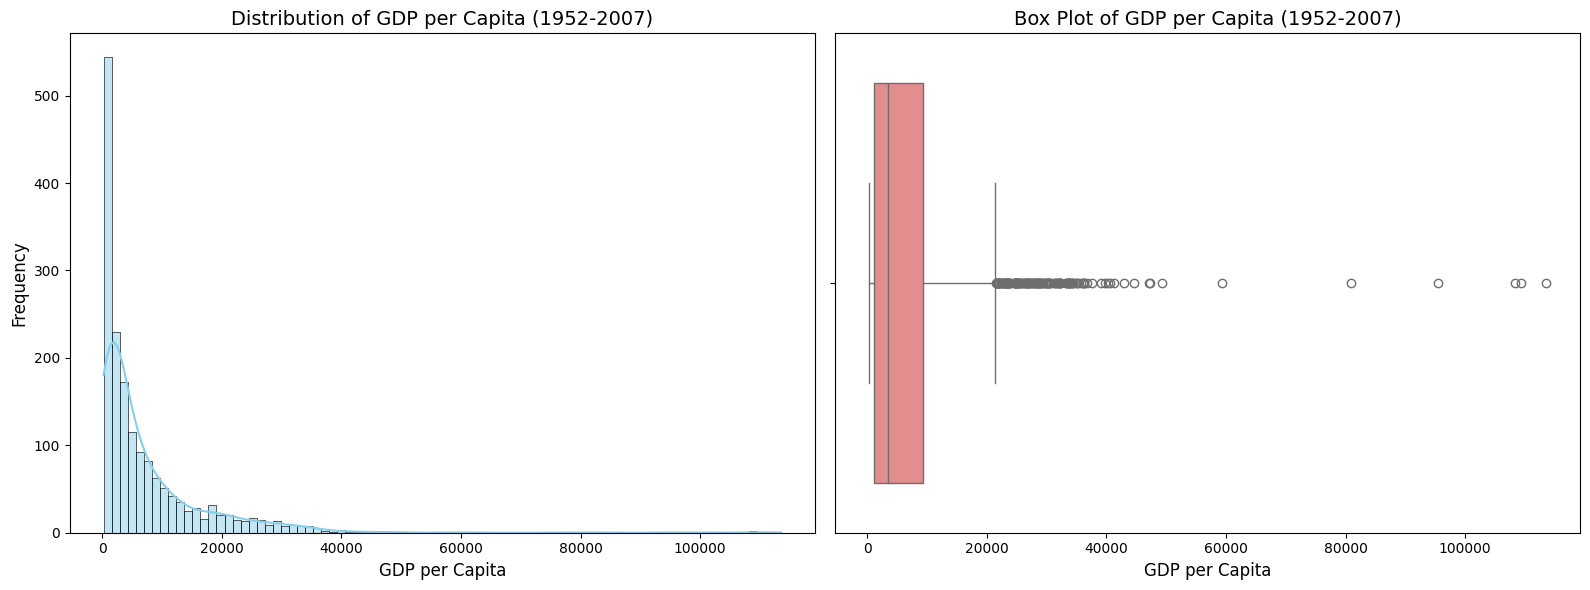

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate skewness
skewness_gdp = df_mckinsey['gdp_cap'].skew()
print(f"Skewness of GDP per Capita: {skewness_gdp:.2f}")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE to visualize the distribution
sns.histplot(df_mckinsey['gdp_cap'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of GDP per Capita (1952-2007)', fontsize=14)
axes[0].set_xlabel('GDP per Capita', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Box plot to clearly show outliers
sns.boxplot(x=df_mckinsey['gdp_cap'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot of GDP per Capita (1952-2007)', fontsize=14)
axes[1].set_xlabel('GDP per Capita', fontsize=12)

plt.tight_layout()
plt.show()

The histogram visually confirms that the distribution of GDP per capita is **positively skewed (right-skewed)**. The bulk of the countries have lower GDP per capita, while a long tail extends to the right, indicating the presence of a few countries with very high GDP per capita.

The calculated skewness value of `%.2f` is positive, confirming this right-skewness.

The box plot further illustrates this by showing many data points far beyond the upper whisker, which represent these high-GDP countries (outliers), such as Kuwait or Norway, as hinted. The median is closer to the first quartile than to the third, which is another indicator of positive skewness.